In [125]:
from MyPlotRecipe.SharedX import ShareXaxis
from MyPlotRecipe.UniversalColor import UniversalColor
from MyPlotRecipe.legend_shadow import legend_shadow
import numpy as np
import math

from scipy import signal
import matplotlib.pyplot as plt
import matplotlib.ticker as ptick
from matplotlib.ticker import FixedLocator

from CSField import CSField
import JupiterMag as jm

jm.Internal.Config(Model='jrm09', CartesianIn=True,
                   CartesianOut=True)
jm.Con2020.Config(equation_type='integral')

UC = UniversalColor()
UC.set_palette()

In [126]:
def day2hhmm(decimal_day):
    doy = int(decimal_day)
    rest = decimal_day - doy

    hours = int(rest*24)
    minutes = (rest*24-hours)*60

    if round(minutes) >= 60:
        hours += 1
        minutes = 0
    else:
        minutes = round(minutes)
    return hours, minutes


def hhmm2day(hours, minutes, seconds=0):
    fraction_of_day = hours/24 + minutes/(60*24) + seconds/(60*60*24)
    return fraction_of_day


def fmt_hhmm(decimal_day):
    hours, minutes = day2hhmm(decimal_day)
    hh = '{:02}'.format(hours)
    mm = '{:02}'.format(minutes)
    return hh+':'+mm

In [127]:
# Data from Connerney+2020: PJ index
con20_pj_idx = np.array([1, 3, 4, 5, 6,
                        7, 8, 9, 10, 11,
                        12, 13, 14, 15, 16,
                        17, 18, 19, 20, 21,
                        22, 23, 24], dtype=int)

# Data from Connerney+2020: Current constant [nT]
con20_mu_i_tot = np.array([150.1, 137.8, 127.2, 129.1, 130.1,
                           142.3, 140.1, 143.8, 137.0, 141.4,
                           124.2, 148.9, 145.3, 144.8, 149.9,
                           132.1, 133.5, 152.9, 138.5, 138.8,
                           156.1, 141.4, 146.3])

# Data from Connerney+2020: Radial current constant [MA]
con20_mu_i_rho = np.array([35.2, 14.6, 7.7, 11.5, 20.8,
                           20.2, 12.2, 21.1, 20.9, 10.7,
                           26.26, 16.4, 12.0, 19.6, 12.0,
                           13.6, 20.0, 12.8, 16.0, 17.3,
                           9.9, 16.1, 10.3])

In [128]:
# 定数
RJ = 71492*1E+3  # Jupiter radius [m]
RE = 1560*1E+3   # Europa radius [m]
# Angular velocity of Jupiter System III rotation [rad sec-1]
OMG_J = 2*np.pi/(9.55*3600)
OMG_G = 2*np.pi/(7.2*24*3600)   # Ganymede orbital angular velosity [rad/sec]

Psyn_eu = (11.22)*3600      # Moon's synodic period [sec]
Psyn_ga = (10.53)*3600      # Moon's synodic period [sec]

# PJ6のデータを読み込む

In [197]:
date_list = ['2017DOY137', '2017DOY138',
             '2017DOY139', '2017DOY140',
             '2017DOY141']
time_list = []
Bx_pc = []
By_pc = []
Bz_pc = []
rx_pc = []
ry_pc = []
rz_pc = []
for i in range(len(date_list)):
    dir = '/Users/shin/Documents/Research/Juno/Mag/Codes/data/R3_' + \
        date_list[i]+'/'
    file_date = date_list[i][0:4]+date_list[i][-3:]
    time_list += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_time.txt').tolist()
    Bx_pc += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_Bx.txt').tolist()
    By_pc += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_By.txt').tolist()
    Bz_pc += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_Bz.txt').tolist()
    rx_pc += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_rx.txt').tolist()
    ry_pc += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_ry.txt').tolist()
    rz_pc += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_rz.txt').tolist()

time_arr = np.array(time_list)
Bx_pc = np.array(Bx_pc)
By_pc = np.array(By_pc)
Bz_pc = np.array(Bz_pc)
rx_pc = np.array(rx_pc)/71492.0
ry_pc = np.array(ry_pc)/71492.0
rz_pc = np.array(rz_pc)/71492.0

In [198]:
np.where(np.sqrt(Bx_pc**2+By_pc**2+Bz_pc**2) > 1600.0)

(array([], dtype=int64),)

In [199]:
# 座標
r_pc = np.sqrt(rx_pc**2+ry_pc**2+rz_pc**2)
cos_phi = rx_pc/r_pc
sin_phi = ry_pc/r_pc
cos_theta = rz_pc/r_pc
sin_theta = np.sqrt(rx_pc**2+ry_pc**2)/r_pc
print('Distance [RJ]:', r_pc[0], r_pc[-1])

# Internal field
Bx0_pc = np.zeros(time_arr.size)
By0_pc = np.zeros(time_arr.size)
Bz0_pc = np.zeros(time_arr.size)
for i in range(time_arr.size):
    Bx0_pc[i], By0_pc[i], Bz0_pc[i] = jm.Internal.Field(rx_pc[i],
                                                        ry_pc[i],
                                                        rz_pc[i])  # [nT]
dBx = Bx_pc - Bx0_pc
dBy = By_pc - By0_pc
dBz = Bz_pc - Bz0_pc
dBr = dBx*sin_theta*cos_phi + dBy*sin_theta*sin_phi + dBz*cos_theta
dBtheta = dBx*cos_theta*cos_phi + dBy*cos_theta*sin_phi - dBz*sin_theta
dBphi = -dBx*sin_phi + dBy*cos_phi

# Con2020 original value
jm.Con2020.Config(mu_i=con20_mu_i_tot[np.where(con20_pj_idx == 6)])
dBx1_pc = np.zeros(time_arr.size)
dBy1_pc = np.zeros(time_arr.size)
dBz1_pc = np.zeros(time_arr.size)
for i in range(time_arr.size):
    dBx1_pc[i], dBy1_pc[i], dBz1_pc[i] = jm.Con2020.Field(rx_pc[i],
                                                          ry_pc[i],
                                                          rz_pc[i])  # [nT]
dBr1_pc = dBx1_pc*sin_theta*cos_phi + dBy1_pc * \
    sin_theta*sin_phi + dBz1_pc*cos_theta
dBtheta1_pc = dBx1_pc*cos_theta*cos_phi + \
    dBy1_pc*cos_theta*sin_phi - dBz1_pc*sin_theta
dBphi1_pc = -dBx1_pc*sin_phi + dBy1_pc*cos_phi

Distance [RJ]: 35.14411797418248 39.84789733846085


In [200]:
# DoE model
csfield = CSField()
csfield.config(
    I_rho=16.7,
    I_phi=1.32E-4,
    D=3.4,
    c=13.6*math.sqrt(2),    # 15.0 / 13.9
    d=25.0*math.sqrt(2),    # 24.8 / 25.0
)

dBx2_pc = np.zeros(time_arr.size)
dBy2_pc = np.zeros(time_arr.size)
dBz2_pc = np.zeros(time_arr.size)
for i in range(time_arr.size):
    dBx2_pc[i], dBy2_pc[i], dBz2_pc[i] = csfield.magnetic_field(rx_pc[i],
                                                                ry_pc[i],
                                                                rz_pc[i])  # [T]
dBx2_pc *= 1E+9    # [nT]
dBy2_pc *= 1E+9    # [nT]
dBz2_pc *= 1E+9    # [nT]
dBr2_pc = dBx2_pc*sin_theta*cos_phi + dBy2_pc * \
    sin_theta*sin_phi + dBz2_pc*cos_theta
dBtheta2_pc = dBx2_pc*cos_theta*cos_phi + \
    dBy2_pc*cos_theta*sin_phi - dBz2_pc*sin_theta
dBphi2_pc = -dBx2_pc*sin_phi + dBy2_pc*cos_phi

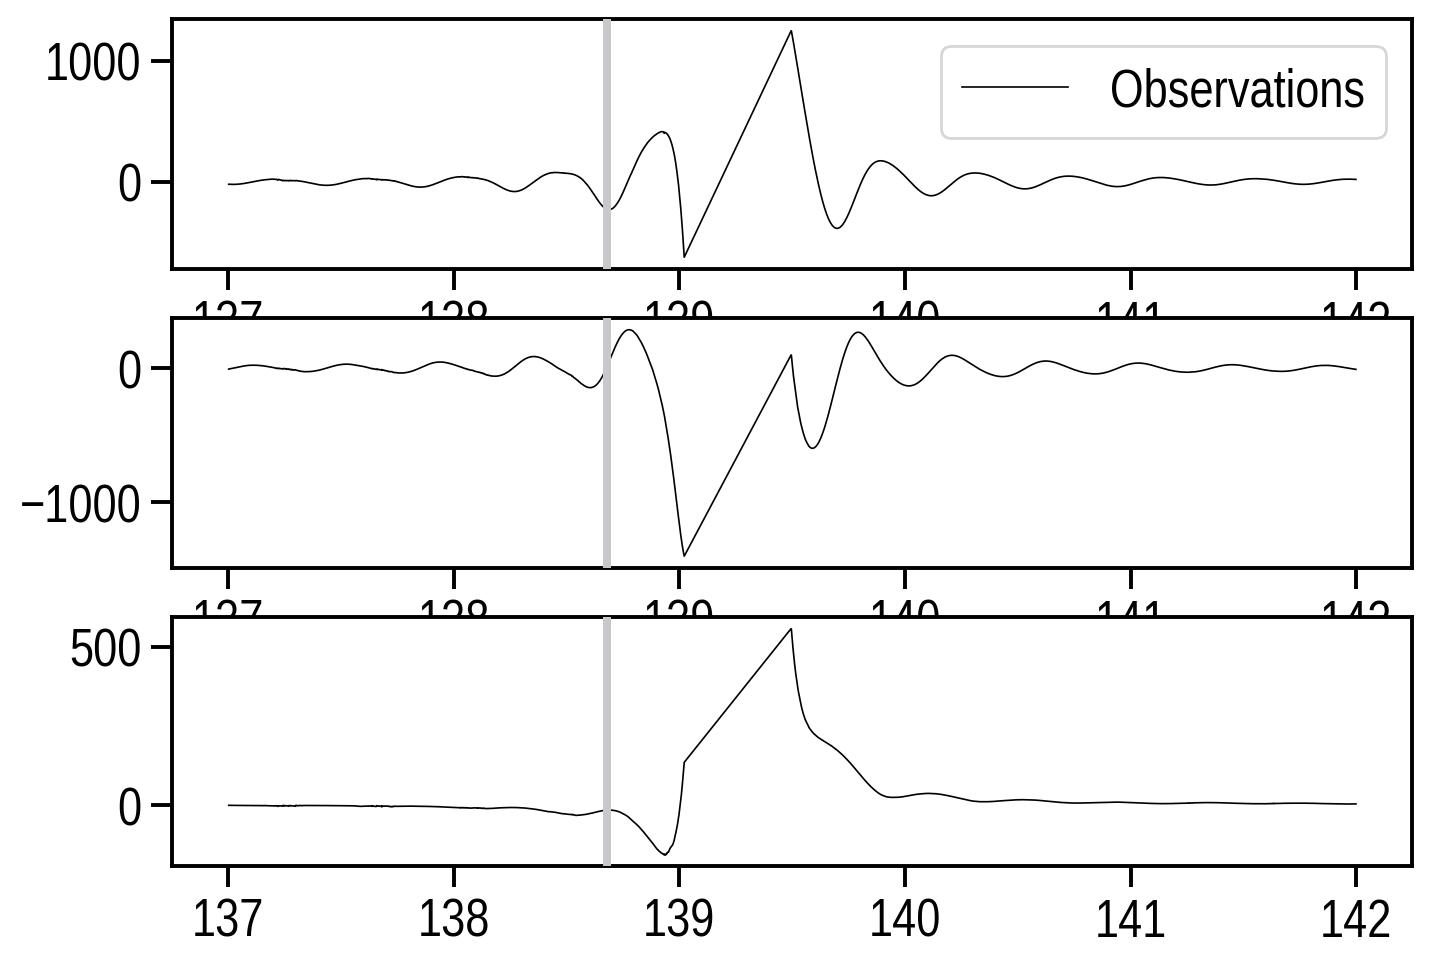

In [201]:
fig, ax = plt.subplots(3, 1, figsize=(8, 5.5), dpi=200)
ax[0].plot(time_arr, Bx_pc, color='k',
           linewidth=0.6, label='Observations', zorder=2.0)
ax[1].plot(time_arr, By_pc, color='k',
           linewidth=0.6, label='Obs', zorder=2.0)
ax[2].plot(time_arr, Bz_pc, color='k',
           linewidth=0.6, label='Obs', zorder=2.0)
ax[0].legend()
for i in range(3):
    ax[i].axvspan(xmin=time_arr[1195], xmax=time_arr[1220],
                  facecolor=UC.lightgray, zorder=3)

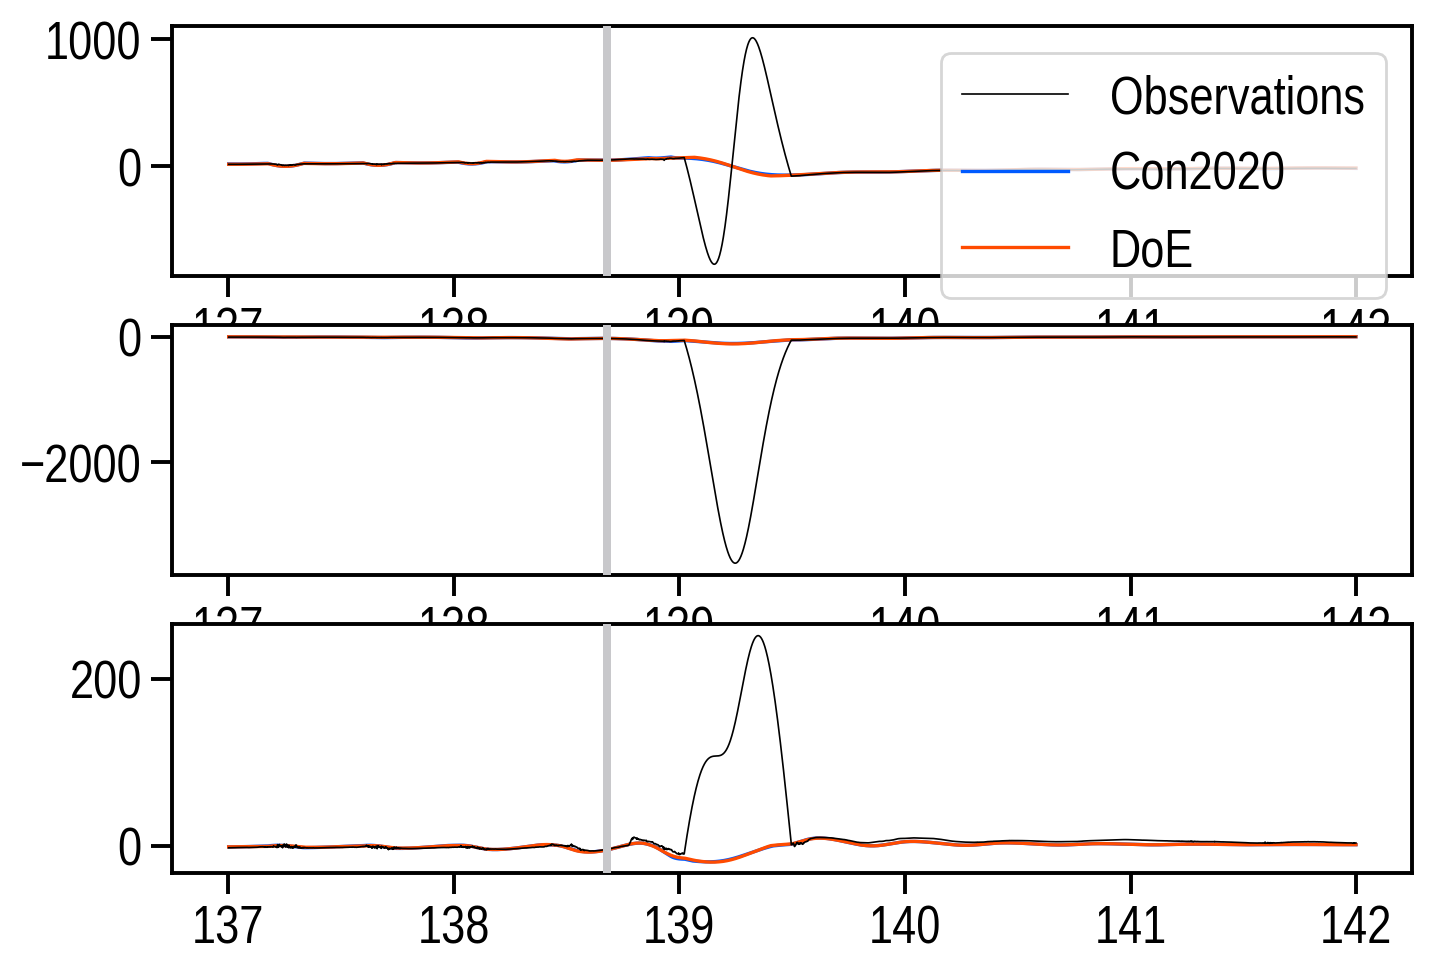

In [202]:
fig, ax = plt.subplots(3, 1, figsize=(8, 5.5), dpi=200)
ax[0].plot(time_arr, dBr, color='k',
           linewidth=0.6, label='Observations', zorder=2.0)
ax[0].plot(time_arr, dBr1_pc, color=UC.blue,
           linewidth=1.2, label='Con2020', zorder=1.0)
ax[0].plot(time_arr, dBr2_pc, color=UC.red,
           linewidth=1.2, label='DoE', zorder=1.0)
ax[1].plot(time_arr, dBtheta, color='k',
           linewidth=0.6, label='Obs', zorder=2.0)
ax[1].plot(time_arr, dBtheta1_pc, color=UC.blue,
           linewidth=1.2, label='Con2020', zorder=1.0)
ax[1].plot(time_arr, dBtheta2_pc, color=UC.red,
           linewidth=1.2, label='DoE', zorder=1.0)
ax[2].plot(time_arr, dBphi, color='k',
           linewidth=0.6, label='Obs', zorder=2.0)
ax[2].plot(time_arr, dBphi1_pc, color=UC.blue,
           linewidth=1.2, label='Con2020', zorder=1.0)
ax[2].plot(time_arr, dBphi2_pc, color=UC.red,
           linewidth=1.2, label='DoE', zorder=1.0)
ax[0].legend()
for i in range(3):
    ax[i].axvspan(xmin=time_arr[1195], xmax=time_arr[1220],
                  facecolor=UC.lightgray, zorder=3)

In [203]:
# RMSE（Root Mean Squared Error: 二乗平均平方根誤差）
print('Inbound')
print(
    math.sqrt(np.sum((dBr[:1435]-dBr1_pc[:1435])**2)/dBr[:1435].size))
print(
    math.sqrt(np.sum((dBr[:1435]-dBr2_pc[:1435])**2)/dBr[:1435].size))
print(
    math.sqrt(np.sum((dBtheta[:1435]-dBtheta1_pc[:1435])**2)/dBr[:1435].size))
print(
    math.sqrt(np.sum((dBtheta[:1435]-dBtheta2_pc[:1435])**2)/dBr[:1435].size))
print(
    math.sqrt(np.sum((dBphi[:1435]-dBphi1_pc[:1435])**2)/dBr[:1435].size))
print(
    math.sqrt(np.sum((dBphi[:1435]-dBphi2_pc[:1435])**2)/dBr[:1435].size))

print('Outbound')
print(math.sqrt(np.sum((dBr[1800:]-dBr1_pc[1800:])**2)/dBr[1800:].size))
print(math.sqrt(np.sum((dBr[1800:]-dBr2_pc[1800:])**2)/dBr[1800:].size))
print(
    math.sqrt(np.sum((dBtheta[1800:]-dBtheta1_pc[1800:])**2)/dBr[1800:].size))
print(
    math.sqrt(np.sum((dBtheta[1800:]-dBtheta2_pc[1800:])**2)/dBr[1800:].size))
print(math.sqrt(np.sum((dBphi[1800:]-dBphi1_pc[1800:])**2)/dBr[1800:].size))
print(math.sqrt(np.sum((dBphi[1800:]-dBphi2_pc[1800:])**2)/dBr[1800:].size))

Inbound
4.585952266777754
3.866313523691516
2.1368740286527084
3.576292782124085
2.1795086766361957
2.071758649127431
Outbound
1.8069755666773646
2.320169871979201
2.024683911567172
2.1909206241479473
3.524617848376363
3.528691318886564


In [204]:
print(np.argsort(abs(r_pc-8.0)))

[1436 1799 1800 ... 3592 3593 3594]


In [205]:
print(r_pc[3152])

34.001142504692105


In [206]:
r_ticks = np.array([[33, time_arr[153]],
                    [32, time_arr[222]],
                    [31, time_arr[290]],
                    [30, time_arr[356]],
                    [29, time_arr[421]],
                    [28, time_arr[484]],
                    [27, time_arr[546]],
                    [26, time_arr[606]],
                    [25, time_arr[665]],
                    [24, time_arr[721]],
                    [23, time_arr[832]],
                    [22, time_arr[566]],
                    [21, time_arr[885]],
                    [20, time_arr[937]],
                    [19, time_arr[987]],
                    [18, time_arr[1036]],
                    [17, time_arr[1083]],
                    [16, time_arr[1129]],
                    [15, time_arr[1173]],
                    [14, time_arr[1215]],
                    [13, time_arr[1256]],
                    [12, time_arr[1296]],
                    [11, time_arr[1333]],
                    [10, time_arr[1369]],
                    [9, time_arr[1404]],
                    [8, time_arr[1436]],
                    [8, time_arr[1799]],
                    [9, time_arr[1832]],
                    [10, time_arr[1866]],
                    [11, time_arr[1902]],
                    [12, time_arr[1940]],
                    [13, time_arr[1979]],
                    [14, time_arr[2020]],
                    [15, time_arr[2063]],
                    [16, time_arr[2107]],
                    [17, time_arr[2153]],
                    [18, time_arr[2199]],
                    [19, time_arr[2247]],
                    [20, time_arr[2298]],
                    [21, time_arr[2349]],
                    [22, time_arr[2402]],
                    [23, time_arr[2457]],
                    [24, time_arr[2513]],
                    [25, time_arr[2570]],
                    [26, time_arr[2629]],
                    [27, time_arr[2690]],
                    [28, time_arr[2752]],
                    [29, time_arr[2815]],
                    [30, time_arr[2879]],
                    [31, time_arr[2945]],
                    [32, time_arr[3012]],
                    [33, time_arr[3081]],
                    [34, time_arr[3152]],])
print(r_ticks[1, :])

[ 32.         137.31008106]


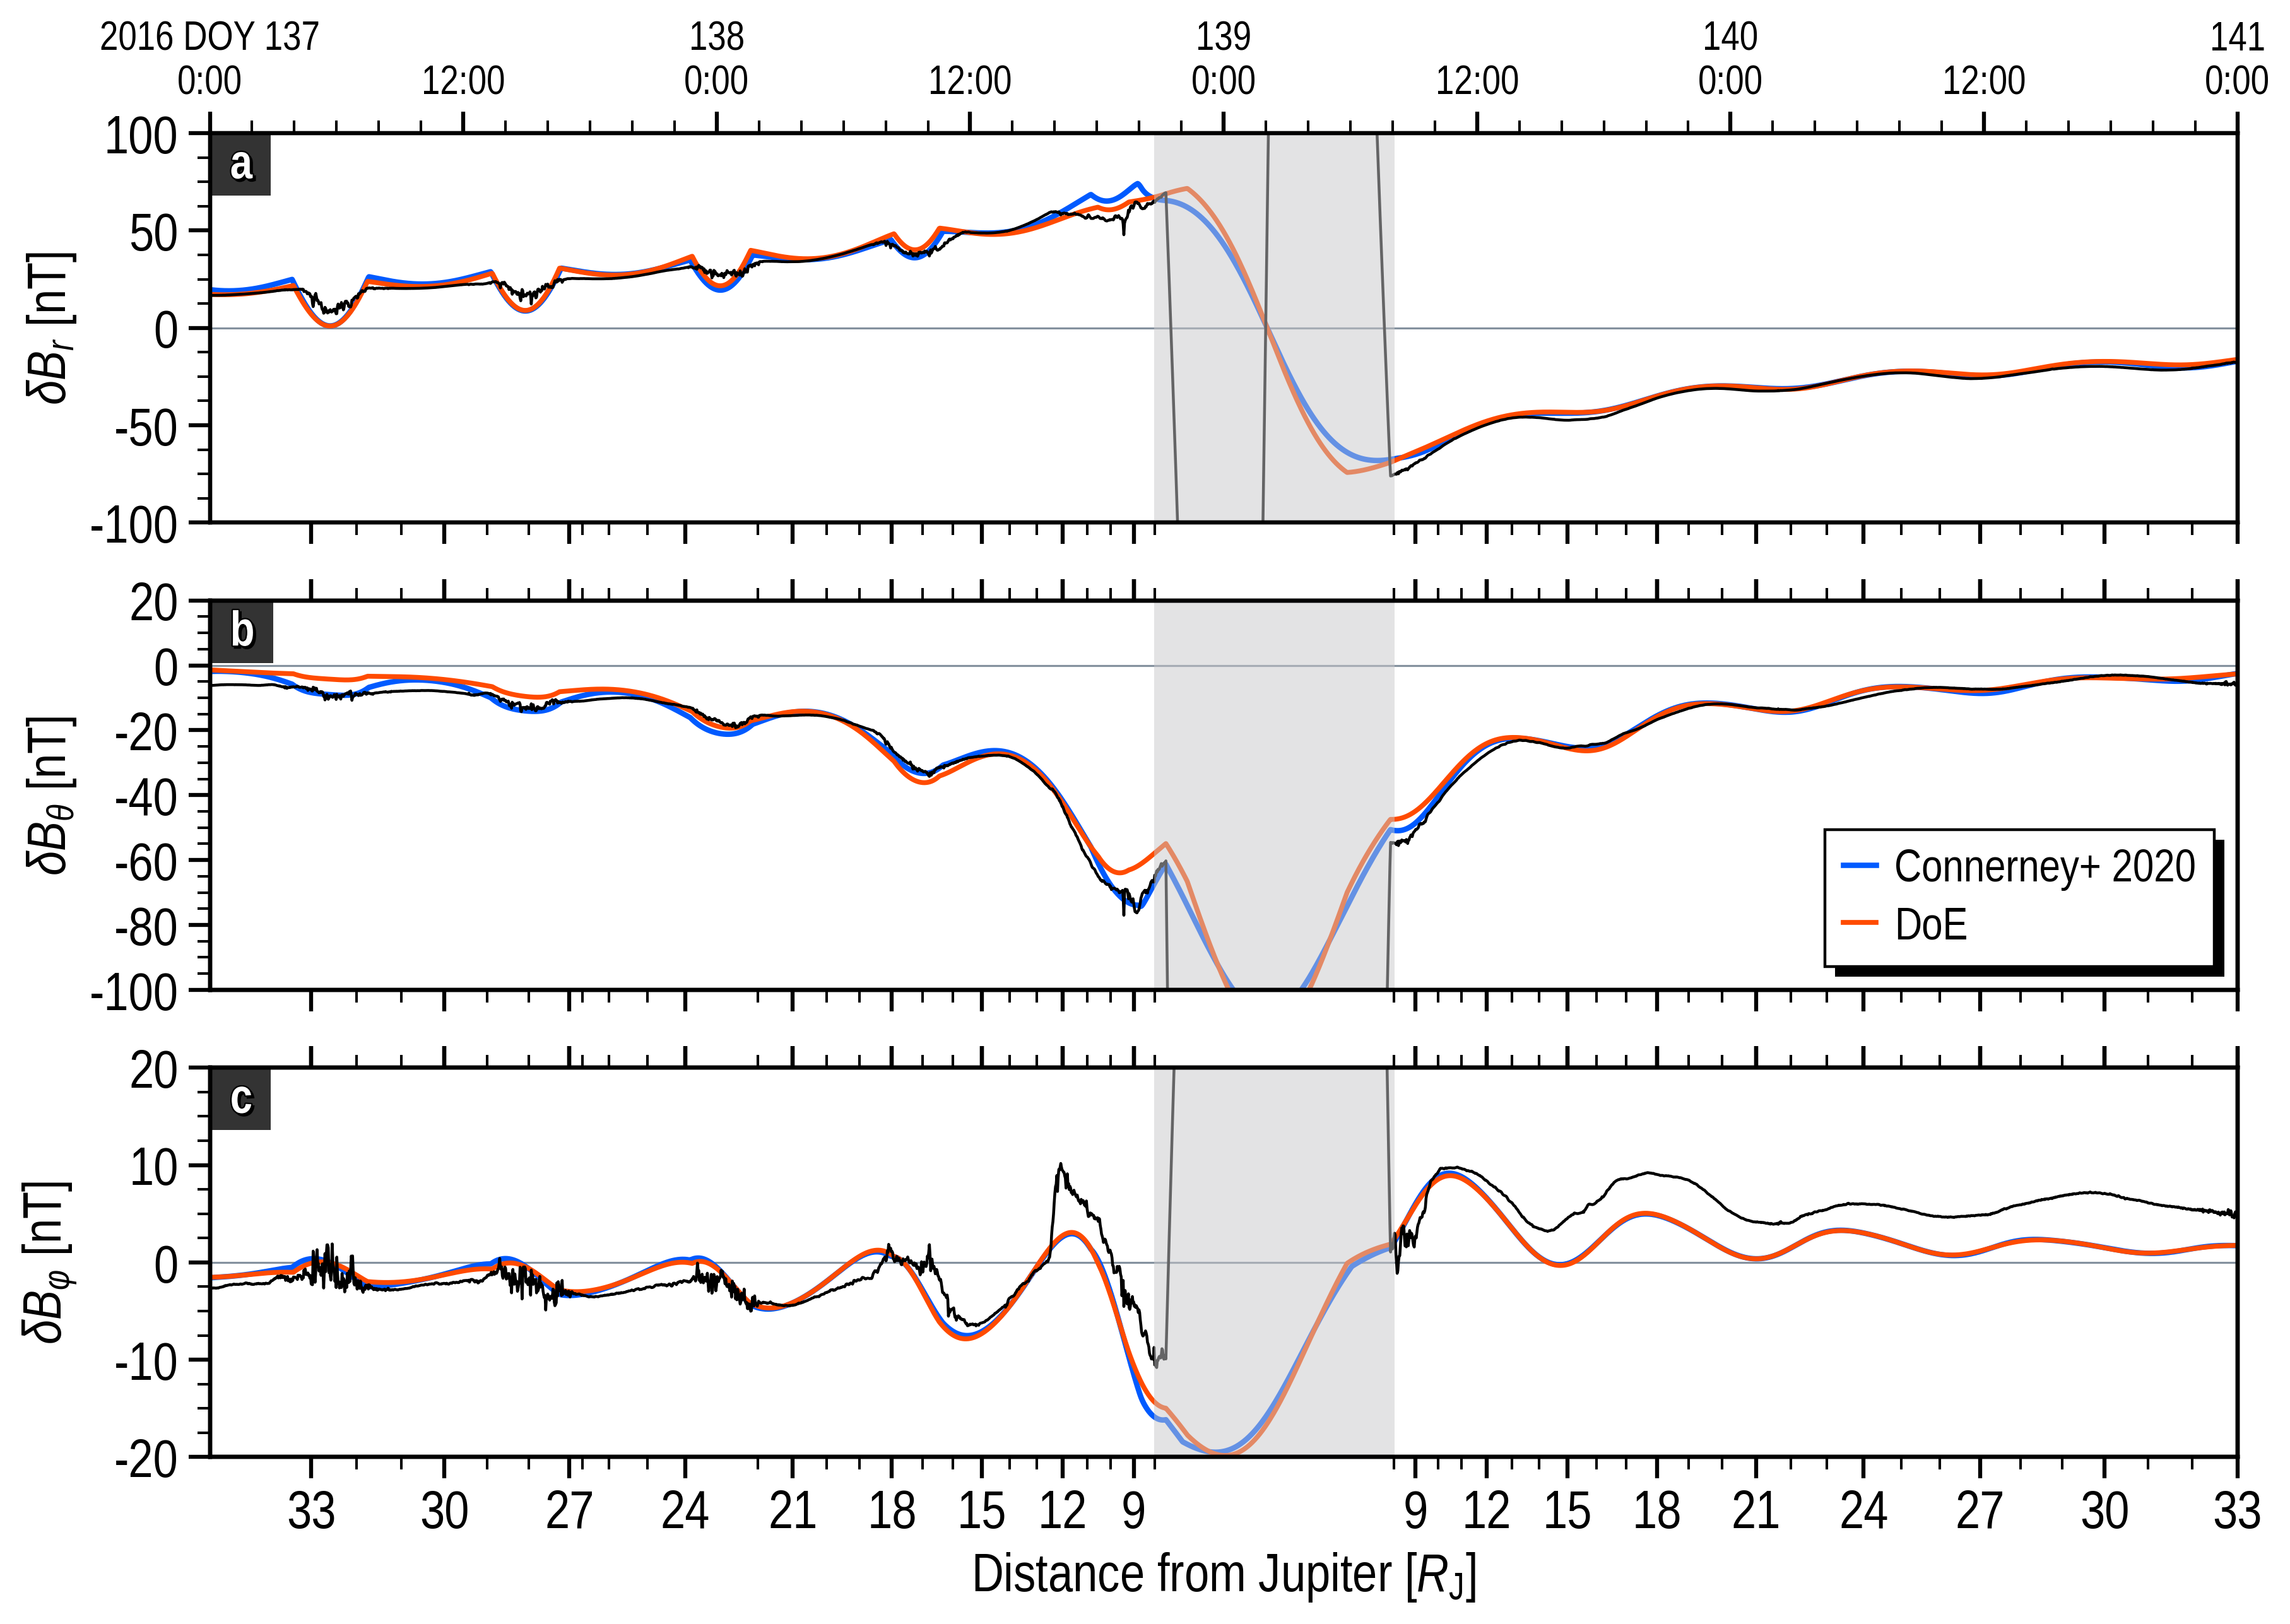

In [207]:
F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=3, figsize=(11.0, 7.5), dpi='XL')
F.hspace = 0.2
F.initialize()

xticks = r_ticks[::3, 1]
xticklabels = r_ticks[::3, 0].astype(int)

F.set_xaxis(label=r'Distance from Jupiter [$R_{\rm J}$]',
            min=137.0, max=141.0,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=None)
for i in range(3):
    F.ax[i].xaxis.set_minor_locator(FixedLocator(r_ticks[:, 1]))
for i in range(2):
    i += 1
    ax_upper = F.ax[i].twiny()
    ax_upper.set_xlim(137.0, 141.0)
    ax_upper.set_xticks(xticks)
    ax_upper.xaxis.set_minor_locator(FixedLocator(r_ticks[:, 1]))
    ax_upper.tick_params(labeltop=False)

F.set_yaxis(ax_idx=0,
            label=r'$\delta B_{r}$ [nT]',
            min=-100, max=100,
            ticks=np.linspace(-100, 100, 5),
            ticklabels=np.linspace(-100, 100, 5, dtype=int),
            minor_num=4)
F.set_yaxis(ax_idx=1,
            label=r'$\delta B_{\theta}$ [nT]',
            min=-100, max=20,
            ticks=np.linspace(-100, 20, 7),
            ticklabels=np.linspace(-100, 20, 7, dtype=int),
            minor_num=4)
F.set_yaxis(ax_idx=2,
            label=r'$\delta B_{\varphi}$ [nT]',
            min=-20, max=20,
            ticks=np.linspace(-20, 20, 5),
            ticklabels=np.linspace(-20, 20, 5, dtype=int),
            minor_num=4)
F.ax[0].plot(time_arr, dBr, color='k',
             linewidth=1.0, label='Observations', zorder=2.0)
F.ax[0].plot(time_arr, dBr1_pc, color=UC.blue,
             linewidth=1.9, label='Connerney+ 2020', zorder=1.0)
F.ax[0].plot(time_arr, dBr2_pc, color=UC.red,
             linewidth=1.7, label='DoE', zorder=1.0)
F.ax[1].plot(time_arr, dBtheta, color='k',
             linewidth=1.0, zorder=2.0)
F.ax[1].plot(time_arr, dBtheta1_pc, color=UC.blue,
             linewidth=1.9, label='Connerney+ 2020', zorder=1.0)
F.ax[1].plot(time_arr, dBtheta2_pc, color=UC.red,
             linewidth=1.7, label='DoE', zorder=1.0)
F.ax[2].plot(time_arr, dBphi, color='k',
             linewidth=1.0, label='Observations', zorder=2.0)
F.ax[2].plot(time_arr, dBphi1_pc, color=UC.blue,
             linewidth=1.9, label='Connerney+ 2020', zorder=1.0)
F.ax[2].plot(time_arr, dBphi2_pc, color=UC.red,
             linewidth=1.7, label='DoE', zorder=1.0)

# Shades near Jupiter
for i in range(F.nrows):
    F.ax[i].axvspan(time_arr[1435], time_arr[1800],
                    fc=UC.lightgray, ec=None,
                    alpha=0.5, zorder=2.5)

# y = 0 line
for i in range(F.nrows):
    F.ax[i].axhline(y=0.0, color=UC.gray, linewidth=0.7, zorder=0.9)

# Time axis
timeax = F.ax[0].twiny()
timeax.set_xlim(137.0, 141.0)
timeax.set_xticks([137.0, 137.5, 138.0, 138.5,
                   139.0, 139.5, 140.0, 140.5,
                   141.0, ])
timeax.set_xticklabels(['2016 DOY 137\n0:00', '12:00',
                        '138\n0:00', '12:00', '139\n0:00', '12:00',
                        '140\n0:00', '12:00', '141\n0:00',], fontsize=F.fontsize*0.75)
timeax.xaxis.set_minor_locator(ptick.AutoMinorLocator(6))

legend = F.legend(ax_idx=1,
                  ncol=1, markerscale=1.0,
                  loc='lower right',
                  handlelength=0.7,
                  textcolor=False,
                  fontsize_scale=0.85,
                  handletextpad=0.4)
legend_shadow(legend=legend, fig=F.fig, ax=F.ax[0], d=0.7)

# PJ12のデータを読み込む

In [208]:
date_list = ['2018DOY090', '2018DOY091',
             '2018DOY092', '2018DOY093',]
time_list = []
Bx_pc = []
By_pc = []
Bz_pc = []
rx_pc = []
ry_pc = []
rz_pc = []
for i in range(len(date_list)):
    dir = '/Users/shin/Documents/Research/Juno/Mag/Codes/data/R3_' + \
        date_list[i]+'/'
    file_date = date_list[i][0:4]+date_list[i][-3:]
    time_list += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_time.txt').tolist()
    Bx_pc += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_Bx.txt').tolist()
    By_pc += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_By.txt').tolist()
    Bz_pc += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_Bz.txt').tolist()
    rx_pc += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_rx.txt').tolist()
    ry_pc += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_ry.txt').tolist()
    rz_pc += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_rz.txt').tolist()

time_arr = np.array(time_list)
Bx_pc = np.array(Bx_pc)
By_pc = np.array(By_pc)
Bz_pc = np.array(Bz_pc)
rx_pc = np.array(rx_pc)/71492.0
ry_pc = np.array(ry_pc)/71492.0
rz_pc = np.array(rz_pc)/71492.0

In [209]:
np.where(np.sqrt(Bx_pc**2+By_pc**2+Bz_pc**2) > 1600.0)

(array([], dtype=int64),)

In [210]:
# 座標
r_pc = np.sqrt(rx_pc**2+ry_pc**2+rz_pc**2)
cos_phi = rx_pc/r_pc
sin_phi = ry_pc/r_pc
cos_theta = rz_pc/r_pc
sin_theta = np.sqrt(rx_pc**2+ry_pc**2)/r_pc
print('Distance [RJ]:', r_pc[0], r_pc[-1])

# Internal field
Bx0_pc = np.zeros(time_arr.size)
By0_pc = np.zeros(time_arr.size)
Bz0_pc = np.zeros(time_arr.size)
for i in range(time_arr.size):
    Bx0_pc[i], By0_pc[i], Bz0_pc[i] = jm.Internal.Field(rx_pc[i],
                                                        ry_pc[i],
                                                        rz_pc[i])  # [nT]
dBx = Bx_pc - Bx0_pc
dBy = By_pc - By0_pc
dBz = Bz_pc - Bz0_pc
dBr = dBx*sin_theta*cos_phi + dBy*sin_theta*sin_phi + dBz*cos_theta
dBtheta = dBx*cos_theta*cos_phi + dBy*cos_theta*sin_phi - dBz*sin_theta
dBphi = -dBx*sin_phi + dBy*cos_phi

# Con2020 original value
jm.Con2020.Config(mu_i=con20_mu_i_tot[np.where(con20_pj_idx == 12)])
dBx1_pc = np.zeros(time_arr.size)
dBy1_pc = np.zeros(time_arr.size)
dBz1_pc = np.zeros(time_arr.size)
for i in range(time_arr.size):
    dBx1_pc[i], dBy1_pc[i], dBz1_pc[i] = jm.Con2020.Field(rx_pc[i],
                                                          ry_pc[i],
                                                          rz_pc[i])  # [nT]
dBr1_pc = dBx1_pc*sin_theta*cos_phi + dBy1_pc * \
    sin_theta*sin_phi + dBz1_pc*cos_theta
dBtheta1_pc = dBx1_pc*cos_theta*cos_phi + \
    dBy1_pc*cos_theta*sin_phi - dBz1_pc*sin_theta
dBphi1_pc = -dBx1_pc*sin_phi + dBy1_pc*cos_phi

Distance [RJ]: 25.975128863568553 38.422900696254395


In [227]:
# DoE model
csfield = CSField()
csfield.config(
    I_rho=16.7,
    I_phi=1.3E-4,
    D=3.6,
    c=13.6*math.sqrt(2),    # 15.0 / 13.9
    d=25.0*math.sqrt(2),    # 24.8 / 25.0
)

dBx2_pc = np.zeros(time_arr.size)
dBy2_pc = np.zeros(time_arr.size)
dBz2_pc = np.zeros(time_arr.size)
for i in range(time_arr.size):
    dBx2_pc[i], dBy2_pc[i], dBz2_pc[i] = csfield.magnetic_field(rx_pc[i],
                                                                ry_pc[i],
                                                                rz_pc[i])  # [T]
dBx2_pc *= 1E+9    # [nT]
dBy2_pc *= 1E+9    # [nT]
dBz2_pc *= 1E+9    # [nT]
dBr2_pc = dBx2_pc*sin_theta*cos_phi + dBy2_pc * \
    sin_theta*sin_phi + dBz2_pc*cos_theta
dBtheta2_pc = dBx2_pc*cos_theta*cos_phi + \
    dBy2_pc*cos_theta*sin_phi - dBz2_pc*sin_theta
dBphi2_pc = -dBx2_pc*sin_phi + dBy2_pc*cos_phi

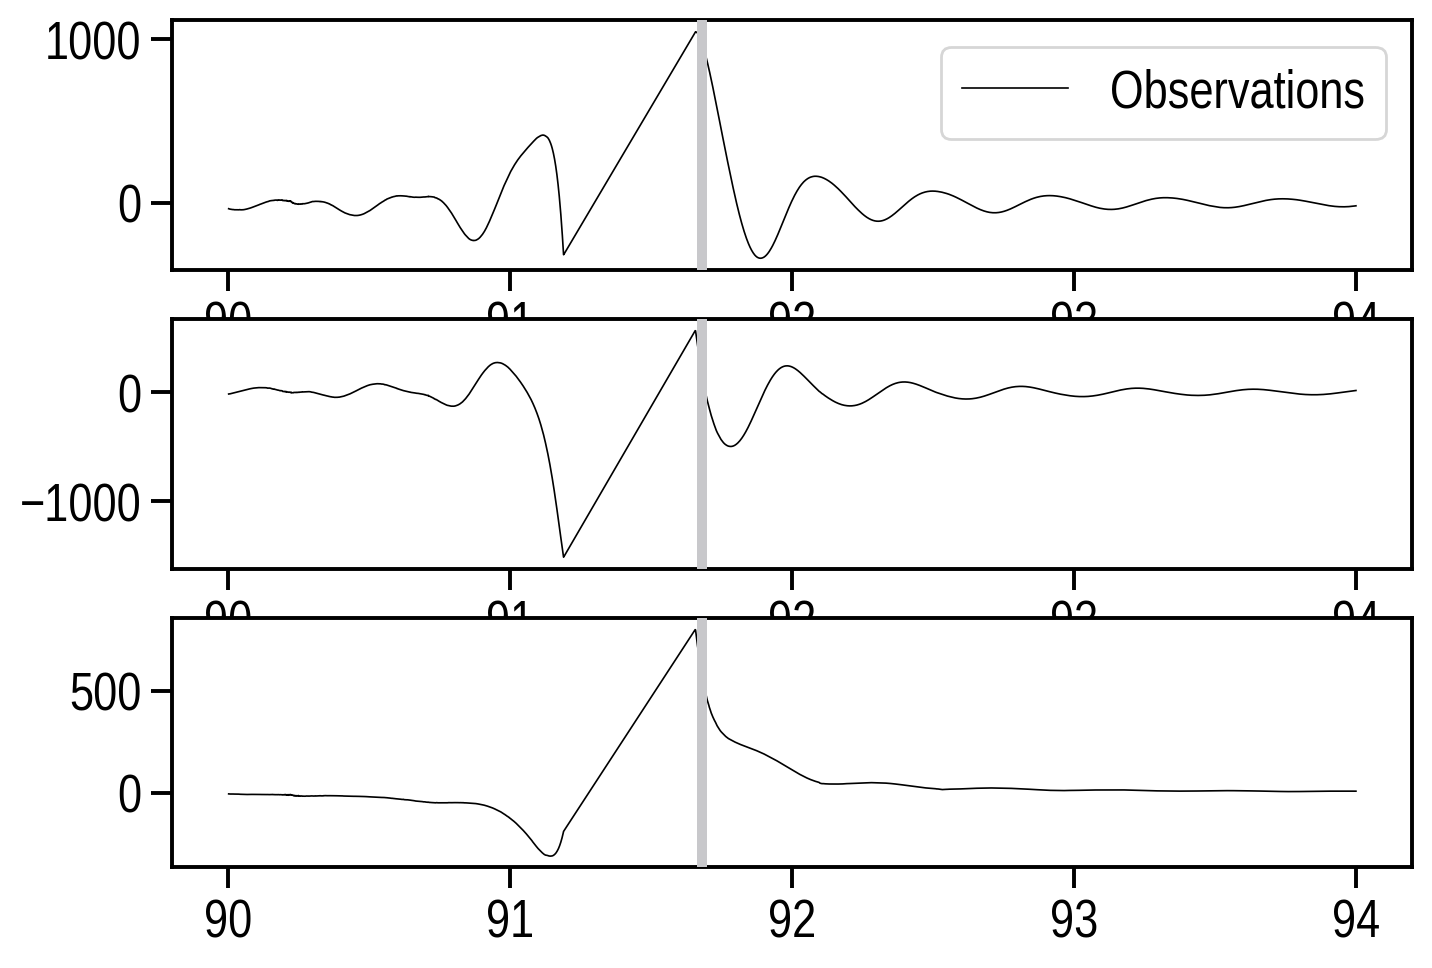

In [228]:
fig, ax = plt.subplots(3, 1, figsize=(8, 5.5), dpi=200)
ax[0].plot(time_arr, Bx_pc, color='k',
           linewidth=0.6, label='Observations', zorder=2.0)
ax[1].plot(time_arr, By_pc, color='k',
           linewidth=0.6, label='Obs', zorder=2.0)
ax[2].plot(time_arr, Bz_pc, color='k',
           linewidth=0.6, label='Obs', zorder=2.0)
ax[0].legend()
for i in range(3):
    ax[i].axvspan(xmin=time_arr[1195], xmax=time_arr[1220],
                  facecolor=UC.lightgray, zorder=3)

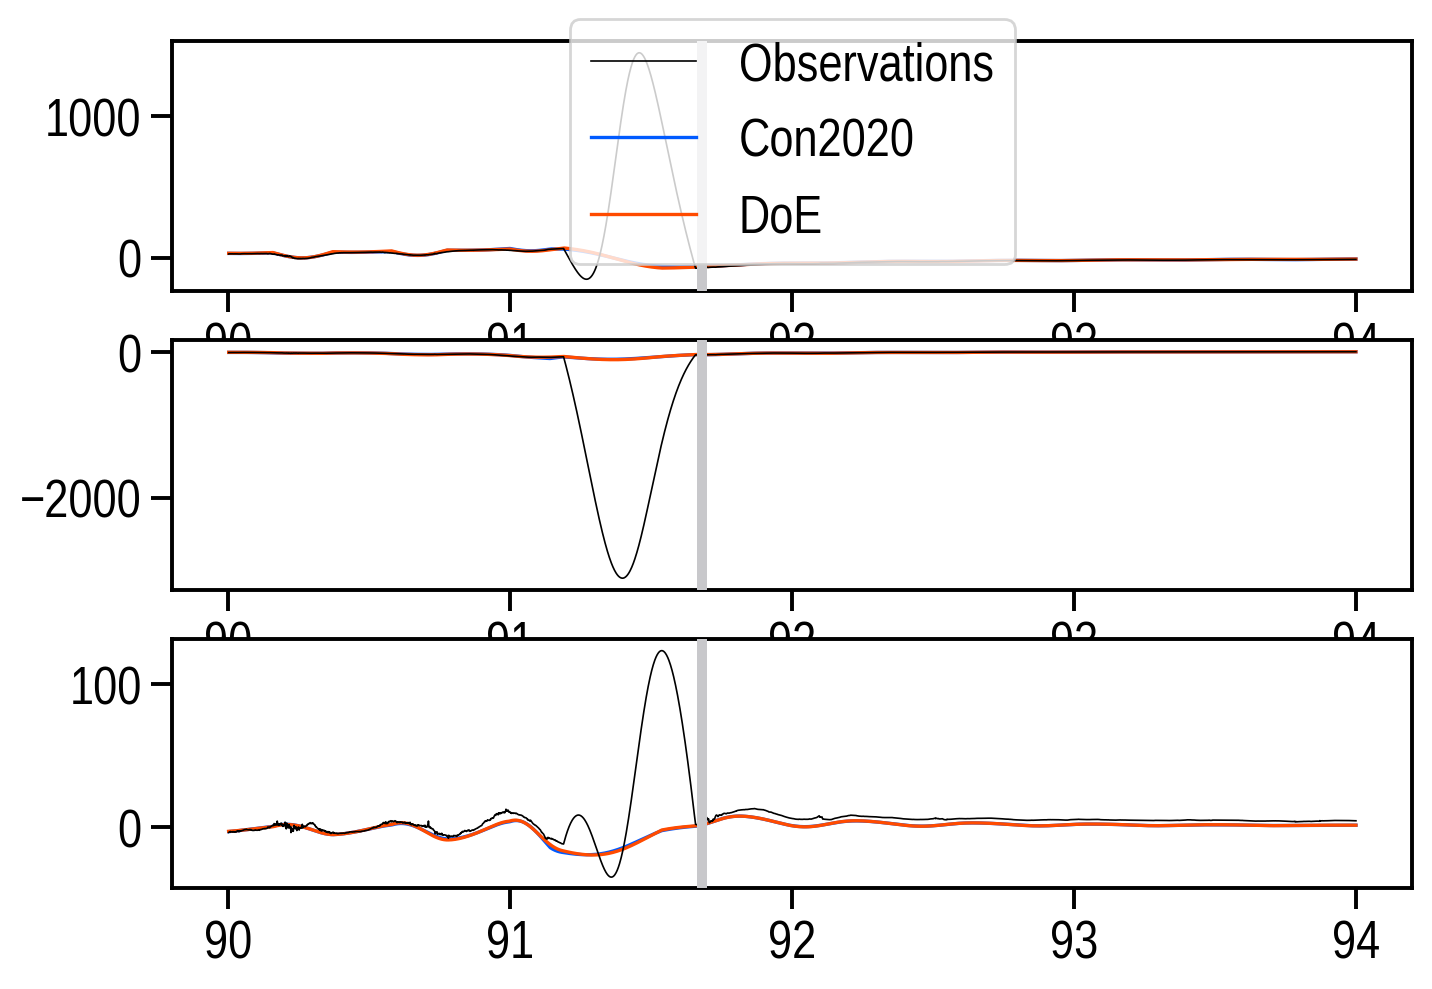

In [229]:
fig, ax = plt.subplots(3, 1, figsize=(8, 5.5), dpi=200)
ax[0].plot(time_arr, dBr, color='k',
           linewidth=0.6, label='Observations', zorder=2.0)
ax[0].plot(time_arr, dBr1_pc, color=UC.blue,
           linewidth=1.2, label='Con2020', zorder=1.0)
ax[0].plot(time_arr, dBr2_pc, color=UC.red,
           linewidth=1.2, label='DoE', zorder=1.0)
ax[1].plot(time_arr, dBtheta, color='k',
           linewidth=0.6, label='Obs', zorder=2.0)
ax[1].plot(time_arr, dBtheta1_pc, color=UC.blue,
           linewidth=1.2, label='Con2020', zorder=1.0)
ax[1].plot(time_arr, dBtheta2_pc, color=UC.red,
           linewidth=1.2, label='DoE', zorder=1.0)
ax[2].plot(time_arr, dBphi, color='k',
           linewidth=0.6, label='Obs', zorder=2.0)
ax[2].plot(time_arr, dBphi1_pc, color=UC.blue,
           linewidth=1.2, label='Con2020', zorder=1.0)
ax[2].plot(time_arr, dBphi2_pc, color=UC.red,
           linewidth=1.2, label='DoE', zorder=1.0)
ax[0].legend()
for i in range(3):
    ax[i].axvspan(xmin=time_arr[1195], xmax=time_arr[1220],
                  facecolor=UC.lightgray, zorder=3)

In [230]:
# RMSE（Root Mean Squared Error: 二乗平均平方根誤差）
print('Inbound')
print(
    math.sqrt(np.sum((dBr[:830]-dBr1_pc[:830])**2)/dBr[:830].size))
print(
    math.sqrt(np.sum((dBr[:830]-dBr2_pc[:830])**2)/dBr[:830].size))
print(
    math.sqrt(np.sum((dBtheta[:830]-dBtheta1_pc[:830])**2)/dBr[:830].size))
print(
    math.sqrt(np.sum((dBtheta[:830]-dBtheta2_pc[:830])**2)/dBr[:830].size))
print(
    math.sqrt(np.sum((dBphi[:830]-dBphi1_pc[:830])**2)/dBr[:830].size))
print(
    math.sqrt(np.sum((dBphi[:830]-dBphi2_pc[:830])**2)/dBr[:830].size))

print('Outbound')
print(math.sqrt(np.sum((dBr[1193:]-dBr1_pc[1193:])**2)/dBr[1193:].size))
print(math.sqrt(np.sum((dBr[1193:]-dBr2_pc[1193:])**2)/dBr[1193:].size))
print(
    math.sqrt(np.sum((dBtheta[1193:]-dBtheta1_pc[1193:])**2)/dBr[1193:].size))
print(
    math.sqrt(np.sum((dBtheta[1193:]-dBtheta2_pc[1193:])**2)/dBr[1193:].size))
print(math.sqrt(np.sum((dBphi[1193:]-dBphi1_pc[1193:])**2)/dBr[1193:].size))
print(math.sqrt(np.sum((dBphi[1193:]-dBphi2_pc[1193:])**2)/dBr[1193:].size))

Inbound
4.500148915814317
5.330066447462483
3.9266280534716493
2.699021000173843
3.1552679690845187
3.0530582955568377
Outbound
2.9312781362700484
2.356689580506513
1.259780345273309
1.4696972551186742
3.776949234171346
3.779202923968887


In [231]:
print(np.argsort(abs(r_pc-37.0)))

[2766 2765 2767 ... 1004 1006 1005]


In [232]:
print(r_pc[1193])

8.009932229238613


In [233]:
r_ticks = np.array([[25, time_arr[57]],
                    [24, time_arr[115]],
                    [23, time_arr[171]],
                    [22, time_arr[226]],
                    [21, time_arr[279]],
                    [20, time_arr[330]],
                    [19, time_arr[380]],
                    [18, time_arr[429]],
                    [17, time_arr[476]],
                    [16, time_arr[522]],
                    [15, time_arr[566]],
                    [14, time_arr[609]],
                    [13, time_arr[650]],
                    [12, time_arr[689]],
                    [11, time_arr[726]],
                    [10, time_arr[762]],
                    [9, time_arr[796]],
                    [8, time_arr[829]],
                    [8, time_arr[1193]],
                    [9, time_arr[1225]],
                    [10, time_arr[1260]],
                    [11, time_arr[1296]],
                    [12, time_arr[1333]],
                    [13, time_arr[1373]],
                    [14, time_arr[1414]],
                    [15, time_arr[1455]],
                    [16, time_arr[1499]],
                    [17, time_arr[1545]],
                    [18, time_arr[1592]],
                    [19, time_arr[1641]],
                    [20, time_arr[1691]],
                    [21, time_arr[1743]],
                    [22, time_arr[1796]],
                    [23, time_arr[1850]],
                    [24, time_arr[1906]],
                    [25, time_arr[1964]],
                    [26, time_arr[2023]],
                    [27, time_arr[2083]],
                    [28, time_arr[2145]],
                    [29, time_arr[2207]],
                    [30, time_arr[2272]],
                    [31, time_arr[2338]],
                    [32, time_arr[2406]],
                    [33, time_arr[2475]],
                    [34, time_arr[2545]],
                    [35, time_arr[2617]],
                    [36, time_arr[2691]],
                    [37, time_arr[2766]],])
print(r_ticks[1, :])

[24.         90.16146982]


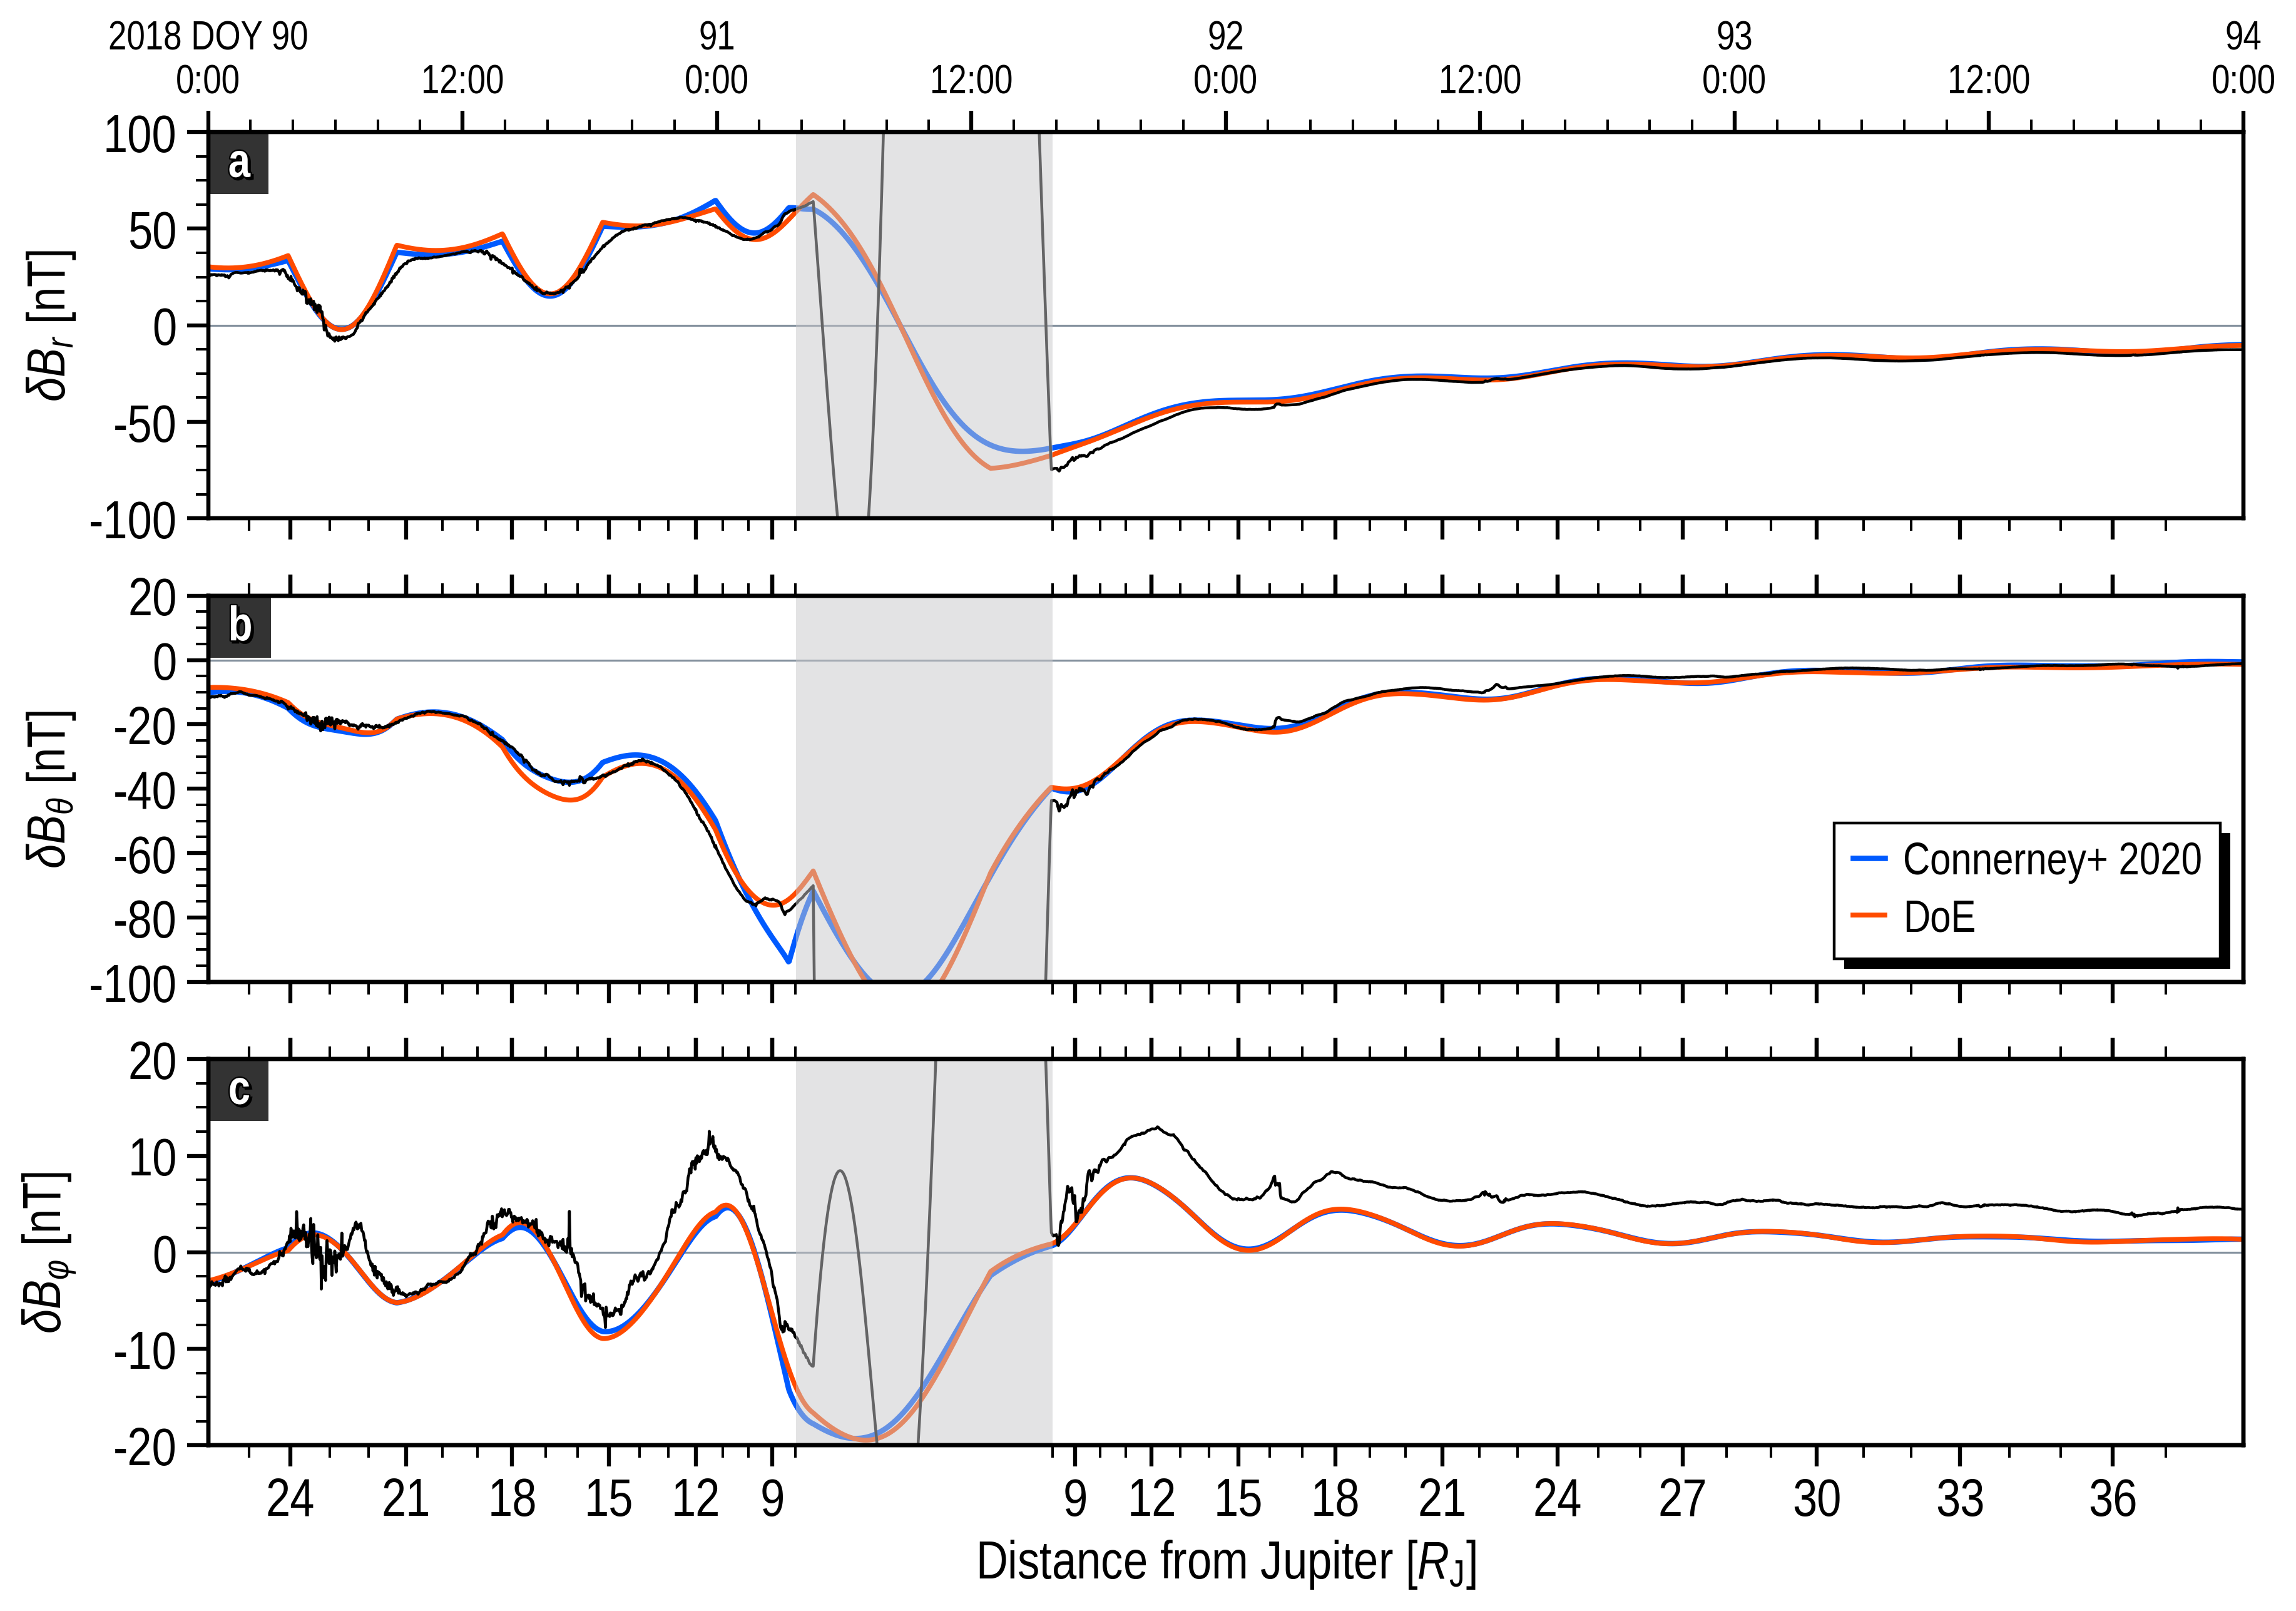

In [234]:
F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=3, figsize=(11.0, 7.5), dpi='XL')
F.hspace = 0.2
F.initialize()

xticks = r_ticks[1::3, 1]
xticklabels = r_ticks[1::3, 0].astype(int)

F.set_xaxis(label=r'Distance from Jupiter [$R_{\rm J}$]',
            min=90.0, max=94.0,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=None)
for i in range(3):
    F.ax[i].xaxis.set_minor_locator(FixedLocator(r_ticks[:, 1]))
for i in range(2):
    i += 1
    ax_upper = F.ax[i].twiny()
    ax_upper.set_xlim(90.0, 94.0)
    ax_upper.set_xticks(xticks)
    ax_upper.xaxis.set_minor_locator(FixedLocator(r_ticks[:, 1]))
    ax_upper.tick_params(labeltop=False)

F.set_yaxis(ax_idx=0,
            label=r'$\delta B_{r}$ [nT]',
            min=-100, max=100,
            ticks=np.linspace(-100, 100, 5),
            ticklabels=np.linspace(-100, 100, 5, dtype=int),
            minor_num=4)
F.set_yaxis(ax_idx=1,
            label=r'$\delta B_{\theta}$ [nT]',
            min=-100, max=20,
            ticks=np.linspace(-100, 20, 7),
            ticklabels=np.linspace(-100, 20, 7, dtype=int),
            minor_num=4)
F.set_yaxis(ax_idx=2,
            label=r'$\delta B_{\varphi}$ [nT]',
            min=-20, max=20,
            ticks=np.linspace(-20, 20, 5),
            ticklabels=np.linspace(-20, 20, 5, dtype=int),
            minor_num=4)
F.ax[0].plot(time_arr, dBr, color='k',
             linewidth=1.0, label='Observations', zorder=2.0)
F.ax[0].plot(time_arr, dBr1_pc, color=UC.blue,
             linewidth=1.9, label='Connerney+ 2020', zorder=1.0)
F.ax[0].plot(time_arr, dBr2_pc, color=UC.red,
             linewidth=1.7, label='DoE', zorder=1.0)
F.ax[1].plot(time_arr, dBtheta, color='k',
             linewidth=1.0, zorder=2.0)
F.ax[1].plot(time_arr, dBtheta1_pc, color=UC.blue,
             linewidth=1.9, label='Connerney+ 2020', zorder=1.0)
F.ax[1].plot(time_arr, dBtheta2_pc, color=UC.red,
             linewidth=1.7, label='DoE', zorder=1.0)
F.ax[2].plot(time_arr, dBphi, color='k',
             linewidth=1.0, label='Observations', zorder=2.0)
F.ax[2].plot(time_arr, dBphi1_pc, color=UC.blue,
             linewidth=1.9, label='Connerney+ 2020', zorder=1.0)
F.ax[2].plot(time_arr, dBphi2_pc, color=UC.red,
             linewidth=1.7, label='DoE', zorder=1.0)

# Shades near Jupiter
for i in range(F.nrows):
    F.ax[i].axvspan(time_arr[830], time_arr[1193],
                    fc=UC.lightgray, ec=None,
                    alpha=0.5, zorder=2.5)

# y = 0 line
for i in range(F.nrows):
    F.ax[i].axhline(y=0.0, color=UC.gray, linewidth=0.7, zorder=0.9)

# Time axis
timeax = F.ax[0].twiny()
timeax.set_xlim(90.0, 94.0)
timeax.set_xticks([90.0, 90.5, 91.0, 91.5,
                   92.0, 92.5, 93.0, 93.5,
                   94.0,])
timeax.set_xticklabels(['2018 DOY 90\n0:00', '12:00',
                        '91\n0:00', '12:00', '92\n0:00', '12:00',
                        '93\n0:00', '12:00', '94\n0:00',], fontsize=F.fontsize*0.75)
timeax.xaxis.set_minor_locator(ptick.AutoMinorLocator(6))

legend = F.legend(ax_idx=1,
                  ncol=1, markerscale=1.0,
                  loc='lower right',
                  handlelength=0.7,
                  textcolor=False,
                  fontsize_scale=0.85,
                  handletextpad=0.4)
legend_shadow(legend=legend, fig=F.fig, ax=F.ax[0], d=0.7)

# PJ16のデータを読み込む

In [140]:
date_list = ['2018DOY301', '2018DOY302',
             '2018DOY303', '2018DOY304',]
time_list = []
Bx_pc = []
By_pc = []
Bz_pc = []
rx_pc = []
ry_pc = []
rz_pc = []
for i in range(len(date_list)):
    dir = '/Users/shin/Documents/Research/Juno/Mag/Codes/data/R3_' + \
        date_list[i]+'/'
    file_date = date_list[i][0:4]+date_list[i][-3:]
    time_list += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_time.txt').tolist()
    Bx_pc += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_Bx.txt').tolist()
    By_pc += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_By.txt').tolist()
    Bz_pc += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_Bz.txt').tolist()
    rx_pc += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_rx.txt').tolist()
    ry_pc += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_ry.txt').tolist()
    rz_pc += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_rz.txt').tolist()

time_arr = np.array(time_list)
Bx_pc = np.array(Bx_pc)
By_pc = np.array(By_pc)
Bz_pc = np.array(Bz_pc)
rx_pc = np.array(rx_pc)/71492.0
ry_pc = np.array(ry_pc)/71492.0
rz_pc = np.array(rz_pc)/71492.0

In [141]:
np.where(np.sqrt(Bx_pc**2+By_pc**2+Bz_pc**2) > 1600.0)

(array([1199, 1200, 1201, 1202, 1203, 1204, 1205, 1206, 1207, 1208, 1209,
        1210, 1211, 1212, 1213, 1214, 1215, 1216, 1217, 1218]),)

In [142]:
# 座標
r_pc = np.sqrt(rx_pc**2+ry_pc**2+rz_pc**2)
cos_phi = rx_pc/r_pc
sin_phi = ry_pc/r_pc
cos_theta = rz_pc/r_pc
sin_theta = np.sqrt(rx_pc**2+ry_pc**2)/r_pc

# Internal field
Bx0_pc = np.zeros(time_arr.size)
By0_pc = np.zeros(time_arr.size)
Bz0_pc = np.zeros(time_arr.size)
for i in range(time_arr.size):
    Bx0_pc[i], By0_pc[i], Bz0_pc[i] = jm.Internal.Field(rx_pc[i],
                                                        ry_pc[i],
                                                        rz_pc[i])  # [nT]
dBx = Bx_pc - Bx0_pc
dBy = By_pc - By0_pc
dBz = Bz_pc - Bz0_pc
dBr = dBx*sin_theta*cos_phi + dBy*sin_theta*sin_phi + dBz*cos_theta
dBtheta = dBx*cos_theta*cos_phi + dBy*cos_theta*sin_phi - dBz*sin_theta
dBphi = -dBx*sin_phi + dBy*cos_phi

# Con2020 original value
jm.Con2020.Config(mu_i=con20_mu_i_tot[np.where(con20_pj_idx == 16)])
dBx1_pc = np.zeros(time_arr.size)
dBy1_pc = np.zeros(time_arr.size)
dBz1_pc = np.zeros(time_arr.size)
for i in range(time_arr.size):
    dBx1_pc[i], dBy1_pc[i], dBz1_pc[i] = jm.Con2020.Field(rx_pc[i],
                                                          ry_pc[i],
                                                          rz_pc[i])  # [nT]
dBr1_pc = dBx1_pc*sin_theta*cos_phi + dBy1_pc * \
    sin_theta*sin_phi + dBz1_pc*cos_theta
dBtheta1_pc = dBx1_pc*cos_theta*cos_phi + \
    dBy1_pc*cos_theta*sin_phi - dBz1_pc*sin_theta
dBphi1_pc = -dBx1_pc*sin_phi + dBy1_pc*cos_phi

In [190]:
# DoE model
csfield = CSField()
csfield.config(
    I_rho=16.7,
    I_phi=1.44E-4,
    D=3.4,
    c=13.6*math.sqrt(2),    # 15.0 / 13.9
    d=25.0*math.sqrt(2),    # 24.8 / 25.0
)

dBx2_pc = np.zeros(time_arr.size)
dBy2_pc = np.zeros(time_arr.size)
dBz2_pc = np.zeros(time_arr.size)
for i in range(time_arr.size):
    dBx2_pc[i], dBy2_pc[i], dBz2_pc[i] = csfield.magnetic_field(rx_pc[i],
                                                                ry_pc[i],
                                                                rz_pc[i])  # [T]
dBx2_pc *= 1E+9    # [nT]
dBy2_pc *= 1E+9    # [nT]
dBz2_pc *= 1E+9    # [nT]
dBr2_pc = dBx2_pc*sin_theta*cos_phi + dBy2_pc * \
    sin_theta*sin_phi + dBz2_pc*cos_theta
dBtheta2_pc = dBx2_pc*cos_theta*cos_phi + \
    dBy2_pc*cos_theta*sin_phi - dBz2_pc*sin_theta
dBphi2_pc = -dBx2_pc*sin_phi + dBy2_pc*cos_phi

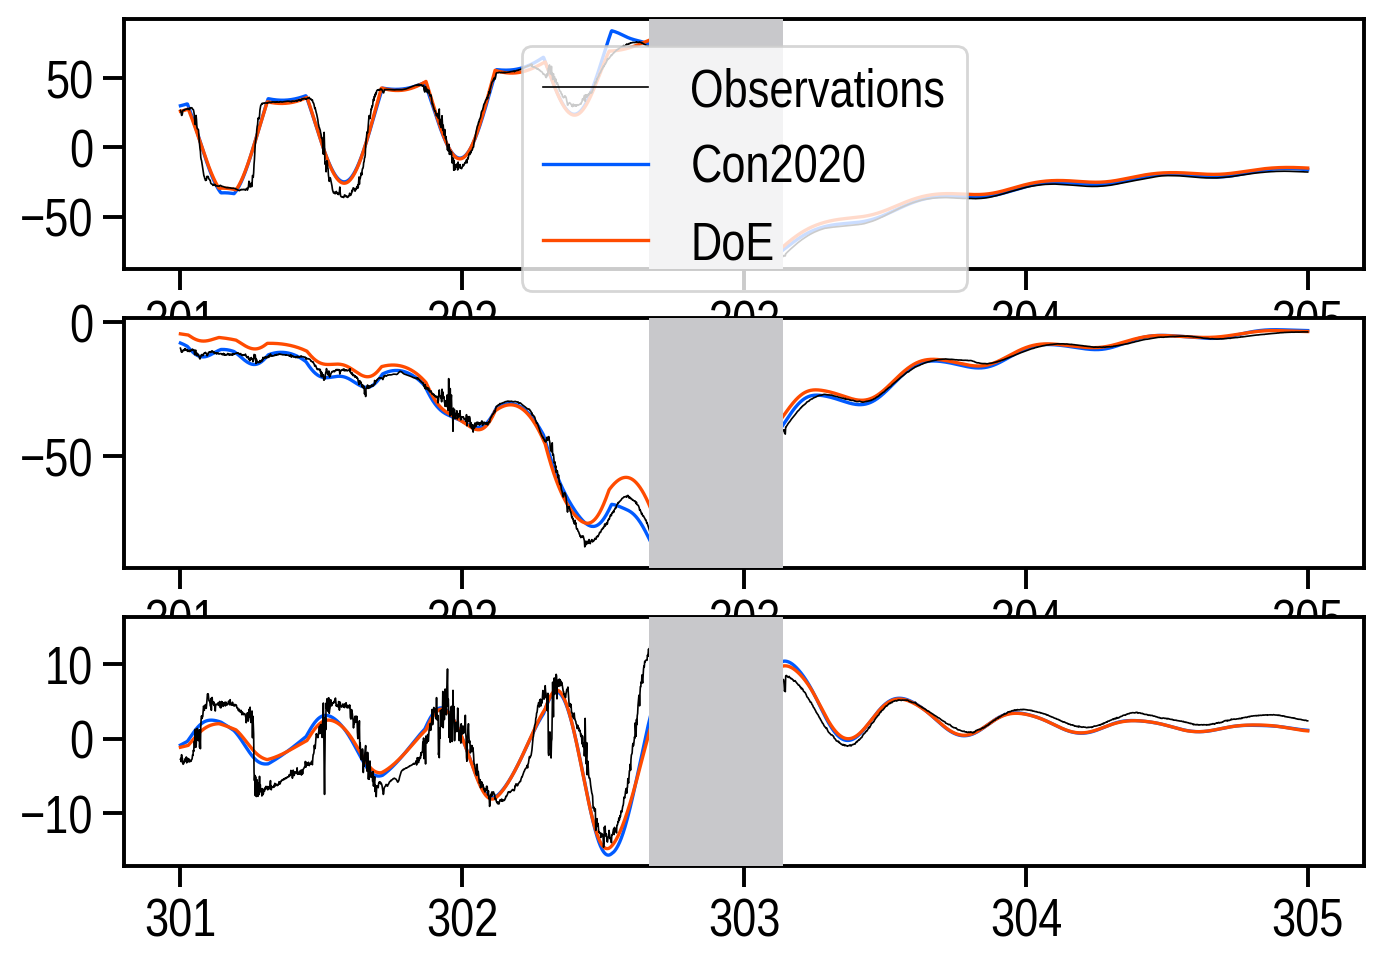

In [191]:
fig, ax = plt.subplots(3, 1, figsize=(8, 5.5), dpi=200)
ax[0].plot(time_arr, dBr, color='k',
           linewidth=0.6, label='Observations', zorder=2.0)
ax[0].plot(time_arr, dBr1_pc, color=UC.blue,
           linewidth=1.2, label='Con2020', zorder=1.0)
ax[0].plot(time_arr, dBr2_pc, color=UC.red,
           linewidth=1.2, label='DoE', zorder=1.0)
ax[1].plot(time_arr, dBtheta, color='k',
           linewidth=0.6, label='Obs', zorder=2.0)
ax[1].plot(time_arr, dBtheta1_pc, color=UC.blue,
           linewidth=1.2, label='Con2020', zorder=1.0)
ax[1].plot(time_arr, dBtheta2_pc, color=UC.red,
           linewidth=1.2, label='DoE', zorder=1.0)
ax[2].plot(time_arr, dBphi, color='k',
           linewidth=0.6, label='Obs', zorder=2.0)
ax[2].plot(time_arr, dBphi1_pc, color=UC.blue,
           linewidth=1.2, label='Con2020', zorder=1.0)
ax[2].plot(time_arr, dBphi2_pc, color=UC.red,
           linewidth=1.2, label='DoE', zorder=1.0)
ax[0].legend()
for i in range(3):
    ax[i].axvspan(xmin=time_arr[1195], xmax=time_arr[1220],
                  facecolor=UC.lightgray, zorder=3)

In [192]:
# RMSE（Root Mean Squared Error: 二乗平均平方根誤差）
print('Inbound')
print(
    math.sqrt(np.sum((dBr[:1195]-dBr1_pc[:1195])**2)/dBr[:1195].size))
print(
    math.sqrt(np.sum((dBr[:1195]-dBr2_pc[:1195])**2)/dBr[:1195].size))
print(
    math.sqrt(np.sum((dBtheta[:1195]-dBtheta1_pc[:1195])**2)/dBr[:1195].size))
print(
    math.sqrt(np.sum((dBtheta[:1195]-dBtheta2_pc[:1195])**2)/dBr[:1195].size))
print(
    math.sqrt(np.sum((dBphi[:1195]-dBphi1_pc[:1195])**2)/dBr[:1195].size))
print(
    math.sqrt(np.sum((dBphi[:1195]-dBphi2_pc[:1195])**2)/dBr[:1195].size))

print('Outbound')
print(math.sqrt(np.sum((dBr[1220:]-dBr1_pc[1220:])**2)/dBr[1220:].size))
print(math.sqrt(np.sum((dBr[1220:]-dBr2_pc[1220:])**2)/dBr[1220:].size))
print(
    math.sqrt(np.sum((dBtheta[1220:]-dBtheta1_pc[1220:])**2)/dBr[1220:].size))
print(
    math.sqrt(np.sum((dBtheta[1220:]-dBtheta2_pc[1220:])**2)/dBr[1220:].size))
print(math.sqrt(np.sum((dBphi[1220:]-dBphi1_pc[1220:])**2)/dBr[1220:].size))
print(math.sqrt(np.sum((dBphi[1220:]-dBphi2_pc[1220:])**2)/dBr[1220:].size))

Inbound
6.8036024338740315
6.036501646202256
2.586548319205919
4.544574807663949
3.2414997590866688
3.2228728876666137
Outbound
1.3655837134803257
3.2783113454375306
1.0572664872640962
1.4779900078051667
0.9950584280944742
0.9640557589820054


In [193]:
print(np.argsort(abs(r_pc-34.0)))

[2560 2559 2558 ... 1216 1217 1218]


In [194]:
print(r_pc[1969])

24.671676549129373


In [195]:
r_ticks = np.array([[31, time_arr[23]],
                    [30, time_arr[89]],
                    [29, time_arr[154]],
                    [28, time_arr[217]],
                    [27, time_arr[279]],
                    [26, time_arr[339]],
                    [25, time_arr[398]],
                    [24, time_arr[456]],
                    [23, time_arr[512]],
                    [22, time_arr[566]],
                    [21, time_arr[619]],
                    [20, time_arr[671]],
                    [19, time_arr[720]],
                    [18, time_arr[768]],
                    [17, time_arr[816]],
                    [16, time_arr[861]],
                    [15, time_arr[905]],
                    [14, time_arr[948]],
                    [13, time_arr[989]],
                    [12, time_arr[1028]],
                    [11, time_arr[1066]],
                    [10, time_arr[1102]],
                    [9, time_arr[1136]],
                    [8, time_arr[1168]],
                    [7, time_arr[1199]],
                    [9, time_arr[1249]],
                    [10, time_arr[1284]],
                    [11, time_arr[1320]],
                    [12, time_arr[1357]],
                    [13, time_arr[1397]],
                    [14, time_arr[1438]],
                    [15, time_arr[1480]],
                    [16, time_arr[1524]],
                    [17, time_arr[1570]],
                    [18, time_arr[1617]],
                    [19, time_arr[1666]],
                    [20, time_arr[1716]],
                    [21, time_arr[1768]],
                    [22, time_arr[1821]],
                    [23, time_arr[1875]],
                    [24, time_arr[1931]],
                    [25, time_arr[1988]],
                    [26, time_arr[2047]],
                    [27, time_arr[2107]],
                    [28, time_arr[2169]],
                    [29, time_arr[2232]],
                    [30, time_arr[2297]],
                    [31, time_arr[2363]],
                    [32, time_arr[2431]],
                    [33, time_arr[2500]],])
print(r_ticks[1, :])

[ 30.         301.12465342]


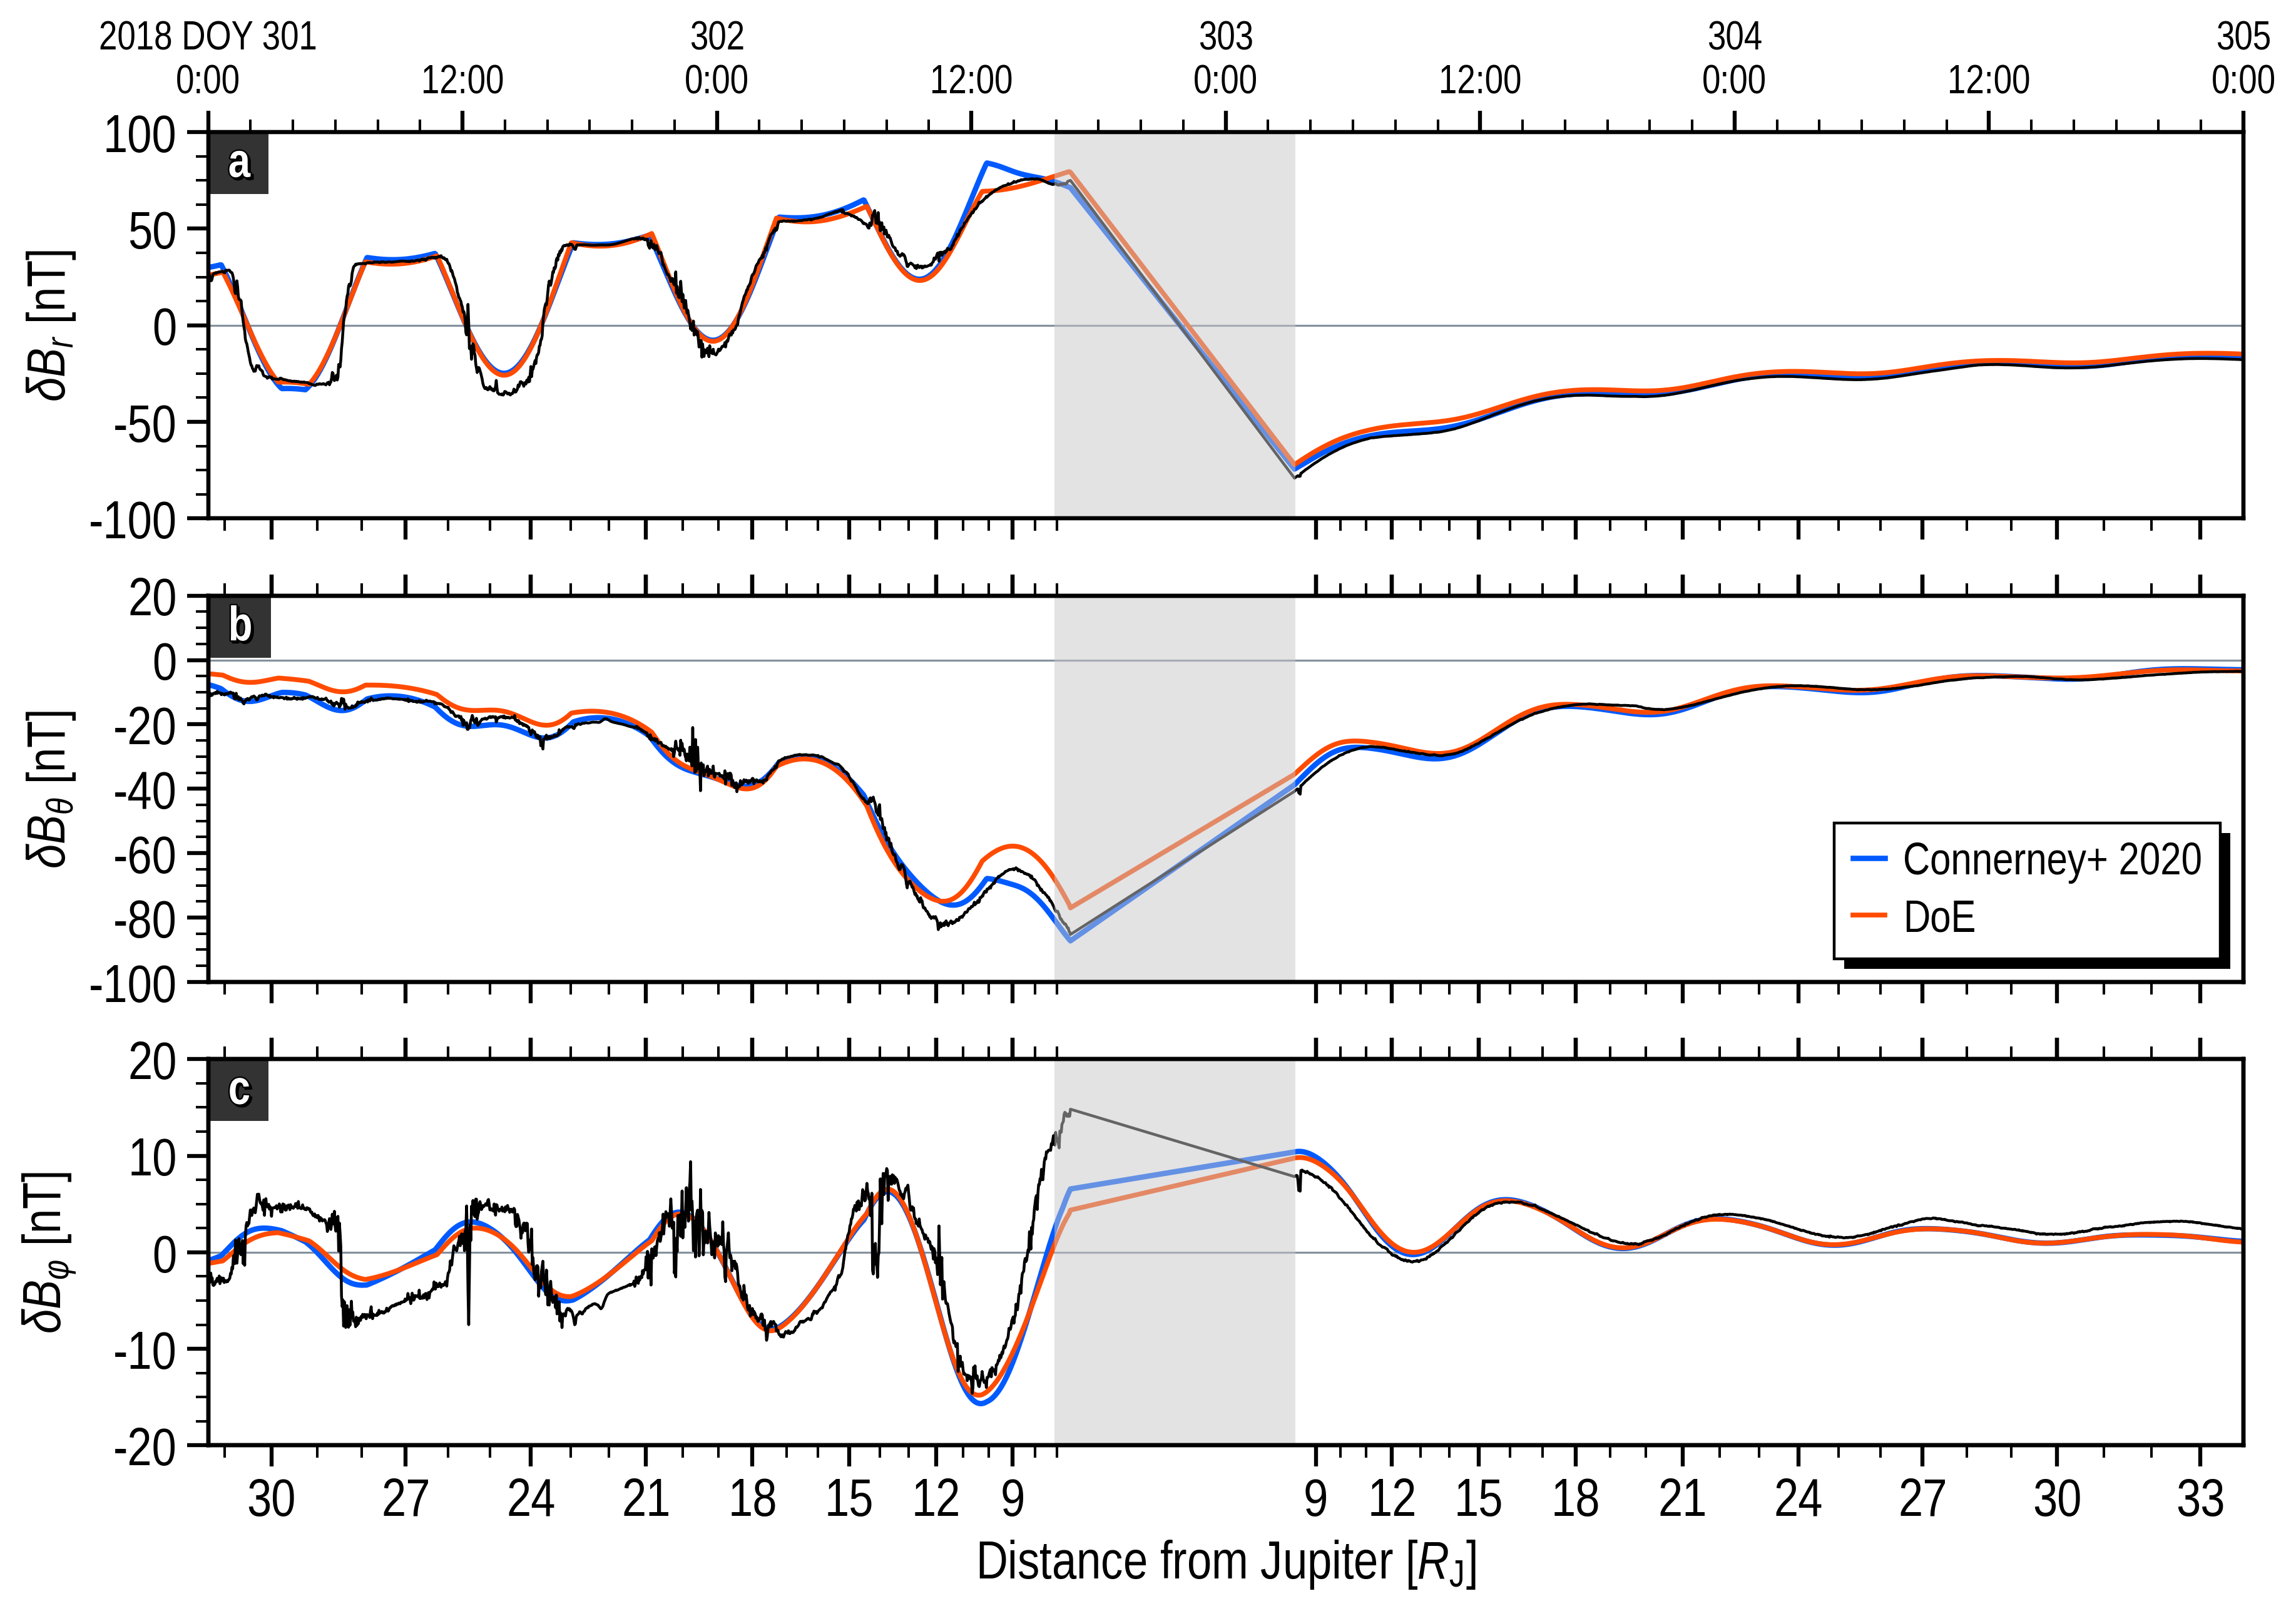

In [196]:
F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=3, figsize=(11.0, 7.5), dpi='XL')
F.hspace = 0.2
F.initialize()

xticks = r_ticks[1::3, 1]
xticklabels = r_ticks[1::3, 0].astype(int)

F.set_xaxis(label=r'Distance from Jupiter [$R_{\rm J}$]',
            min=301.0, max=305.0,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=None)
for i in range(3):
    F.ax[i].xaxis.set_minor_locator(FixedLocator(r_ticks[:, 1]))
for i in range(2):
    i += 1
    ax_upper = F.ax[i].twiny()
    ax_upper.set_xlim(301.0, 305.0)
    ax_upper.set_xticks(xticks)
    ax_upper.xaxis.set_minor_locator(FixedLocator(r_ticks[:, 1]))
    ax_upper.tick_params(labeltop=False)

F.set_yaxis(ax_idx=0,
            label=r'$\delta B_{r}$ [nT]',
            min=-100, max=100,
            ticks=np.linspace(-100, 100, 5),
            ticklabels=np.linspace(-100, 100, 5, dtype=int),
            minor_num=4)
F.set_yaxis(ax_idx=1,
            label=r'$\delta B_{\theta}$ [nT]',
            min=-100, max=20,
            ticks=np.linspace(-100, 20, 7),
            ticklabels=np.linspace(-100, 20, 7, dtype=int),
            minor_num=4)
F.set_yaxis(ax_idx=2,
            label=r'$\delta B_{\varphi}$ [nT]',
            min=-20, max=20,
            ticks=np.linspace(-20, 20, 5),
            ticklabels=np.linspace(-20, 20, 5, dtype=int),
            minor_num=4)
F.ax[0].plot(time_arr, dBr, color='k',
             linewidth=1.0, label='Observations', zorder=2.0)
F.ax[0].plot(time_arr, dBr1_pc, color=UC.blue,
             linewidth=1.9, label='Connerney+ 2020', zorder=1.0)
F.ax[0].plot(time_arr, dBr2_pc, color=UC.red,
             linewidth=1.7, label='DoE', zorder=1.0)
F.ax[1].plot(time_arr, dBtheta, color='k',
             linewidth=1.0, zorder=2.0)
F.ax[1].plot(time_arr, dBtheta1_pc, color=UC.blue,
             linewidth=1.9, label='Connerney+ 2020', zorder=1.0)
F.ax[1].plot(time_arr, dBtheta2_pc, color=UC.red,
             linewidth=1.7, label='DoE', zorder=1.0)
F.ax[2].plot(time_arr, dBphi, color='k',
             linewidth=1.0, label='Observations', zorder=2.0)
F.ax[2].plot(time_arr, dBphi1_pc, color=UC.blue,
             linewidth=1.9, label='Connerney+ 2020', zorder=1.0)
F.ax[2].plot(time_arr, dBphi2_pc, color=UC.red,
             linewidth=1.7, label='DoE', zorder=1.0)

# Shades near Jupiter
for i in range(F.nrows):
    F.ax[i].axvspan(time_arr[1195], time_arr[1220],
                    fc=UC.lightgray, ec=None,
                    alpha=0.5, zorder=2.5)

# y = 0 line
for i in range(F.nrows):
    F.ax[i].axhline(y=0.0, color=UC.gray, linewidth=0.7, zorder=0.9)

# Time axis
timeax = F.ax[0].twiny()
timeax.set_xlim(301.0, 305.0)
timeax.set_xticks([301.0, 301.5,
                   302.0, 302.5, 303.0, 303.5,
                   304.0, 304.5, 305.0])
timeax.set_xticklabels(['2018 DOY 301\n0:00', '12:00',
                        '302\n0:00', '12:00', '303\n0:00', '12:00',
                        '304\n0:00', '12:00', '305\n0:00'], fontsize=F.fontsize*0.75)
timeax.xaxis.set_minor_locator(ptick.AutoMinorLocator(6))

legend = F.legend(ax_idx=1,
                  ncol=1, markerscale=1.0,
                  loc='lower right',
                  handlelength=0.7,
                  textcolor=False,
                  fontsize_scale=0.85,
                  handletextpad=0.4)
legend_shadow(legend=legend, fig=F.fig, ax=F.ax[0], d=0.7)

# PJ17のデータを読み込む

In [235]:
date_list = ['2018DOY354', '2018DOY355',
             '2018DOY356', '2018DOY357',]
time_list = []
Bx_pc = []
By_pc = []
Bz_pc = []
rx_pc = []
ry_pc = []
rz_pc = []
for i in range(len(date_list)):
    dir = '/Users/shin/Documents/Research/Juno/Mag/Codes/data/R3_' + \
        date_list[i]+'/'
    file_date = date_list[i][0:4]+date_list[i][-3:]
    time_list += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_time.txt').tolist()
    Bx_pc += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_Bx.txt').tolist()
    By_pc += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_By.txt').tolist()
    Bz_pc += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_Bz.txt').tolist()
    rx_pc += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_rx.txt').tolist()
    ry_pc += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_ry.txt').tolist()
    rz_pc += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_rz.txt').tolist()

time_arr = np.array(time_list)
Bx_pc = np.array(Bx_pc)
By_pc = np.array(By_pc)
Bz_pc = np.array(Bz_pc)
rx_pc = np.array(rx_pc)/71492.0
ry_pc = np.array(ry_pc)/71492.0
rz_pc = np.array(rz_pc)/71492.0

In [236]:
np.where(np.sqrt(Bx_pc**2+By_pc**2+Bz_pc**2) > 1600.0)

(array([1069, 1070, 1071, 1072, 1073, 1389, 1390, 1391, 1392, 1393, 1394,
        1395, 1396, 1397, 1398, 1399, 1400]),)

In [237]:
# 座標
r_pc = np.sqrt(rx_pc**2+ry_pc**2+rz_pc**2)
cos_phi = rx_pc/r_pc
sin_phi = ry_pc/r_pc
cos_theta = rz_pc/r_pc
sin_theta = np.sqrt(rx_pc**2+ry_pc**2)/r_pc

# Internal field
Bx0_pc = np.zeros(time_arr.size)
By0_pc = np.zeros(time_arr.size)
Bz0_pc = np.zeros(time_arr.size)
for i in range(time_arr.size):
    Bx0_pc[i], By0_pc[i], Bz0_pc[i] = jm.Internal.Field(rx_pc[i],
                                                        ry_pc[i],
                                                        rz_pc[i])  # [nT]
dBx = Bx_pc - Bx0_pc
dBy = By_pc - By0_pc
dBz = Bz_pc - Bz0_pc
dBr = dBx*sin_theta*cos_phi + dBy*sin_theta*sin_phi + dBz*cos_theta
dBtheta = dBx*cos_theta*cos_phi + dBy*cos_theta*sin_phi - dBz*sin_theta
dBphi = -dBx*sin_phi + dBy*cos_phi

# Con2020 original value
jm.Con2020.Config(mu_i=con20_mu_i_tot[np.where(con20_pj_idx == 17)])
dBx1_pc = np.zeros(time_arr.size)
dBy1_pc = np.zeros(time_arr.size)
dBz1_pc = np.zeros(time_arr.size)
for i in range(time_arr.size):
    dBx1_pc[i], dBy1_pc[i], dBz1_pc[i] = jm.Con2020.Field(rx_pc[i],
                                                          ry_pc[i],
                                                          rz_pc[i])  # [nT]
dBr1_pc = dBx1_pc*sin_theta*cos_phi + dBy1_pc * \
    sin_theta*sin_phi + dBz1_pc*cos_theta
dBtheta1_pc = dBx1_pc*cos_theta*cos_phi + \
    dBy1_pc*cos_theta*sin_phi - dBz1_pc*sin_theta
dBphi1_pc = -dBx1_pc*sin_phi + dBy1_pc*cos_phi

In [253]:
# DoE model
csfield = CSField()
csfield.config(
    I_rho=16.7,
    I_phi=1.32E-4,
    D=3.4,
    c=13.6*math.sqrt(2),    # 15.0 / 13.9
    d=25.0*math.sqrt(2),    # 24.8 / 25.0
)

dBx2_pc = np.zeros(time_arr.size)
dBy2_pc = np.zeros(time_arr.size)
dBz2_pc = np.zeros(time_arr.size)
for i in range(time_arr.size):
    dBx2_pc[i], dBy2_pc[i], dBz2_pc[i] = csfield.magnetic_field(rx_pc[i],
                                                                ry_pc[i],
                                                                rz_pc[i])  # [T]
dBx2_pc *= 1E+9    # [nT]
dBy2_pc *= 1E+9    # [nT]
dBz2_pc *= 1E+9    # [nT]
dBr2_pc = dBx2_pc*sin_theta*cos_phi + dBy2_pc * \
    sin_theta*sin_phi + dBz2_pc*cos_theta
dBtheta2_pc = dBx2_pc*cos_theta*cos_phi + \
    dBy2_pc*cos_theta*sin_phi - dBz2_pc*sin_theta
dBphi2_pc = -dBx2_pc*sin_phi + dBy2_pc*cos_phi

8.381986659631037
8.351064919607438


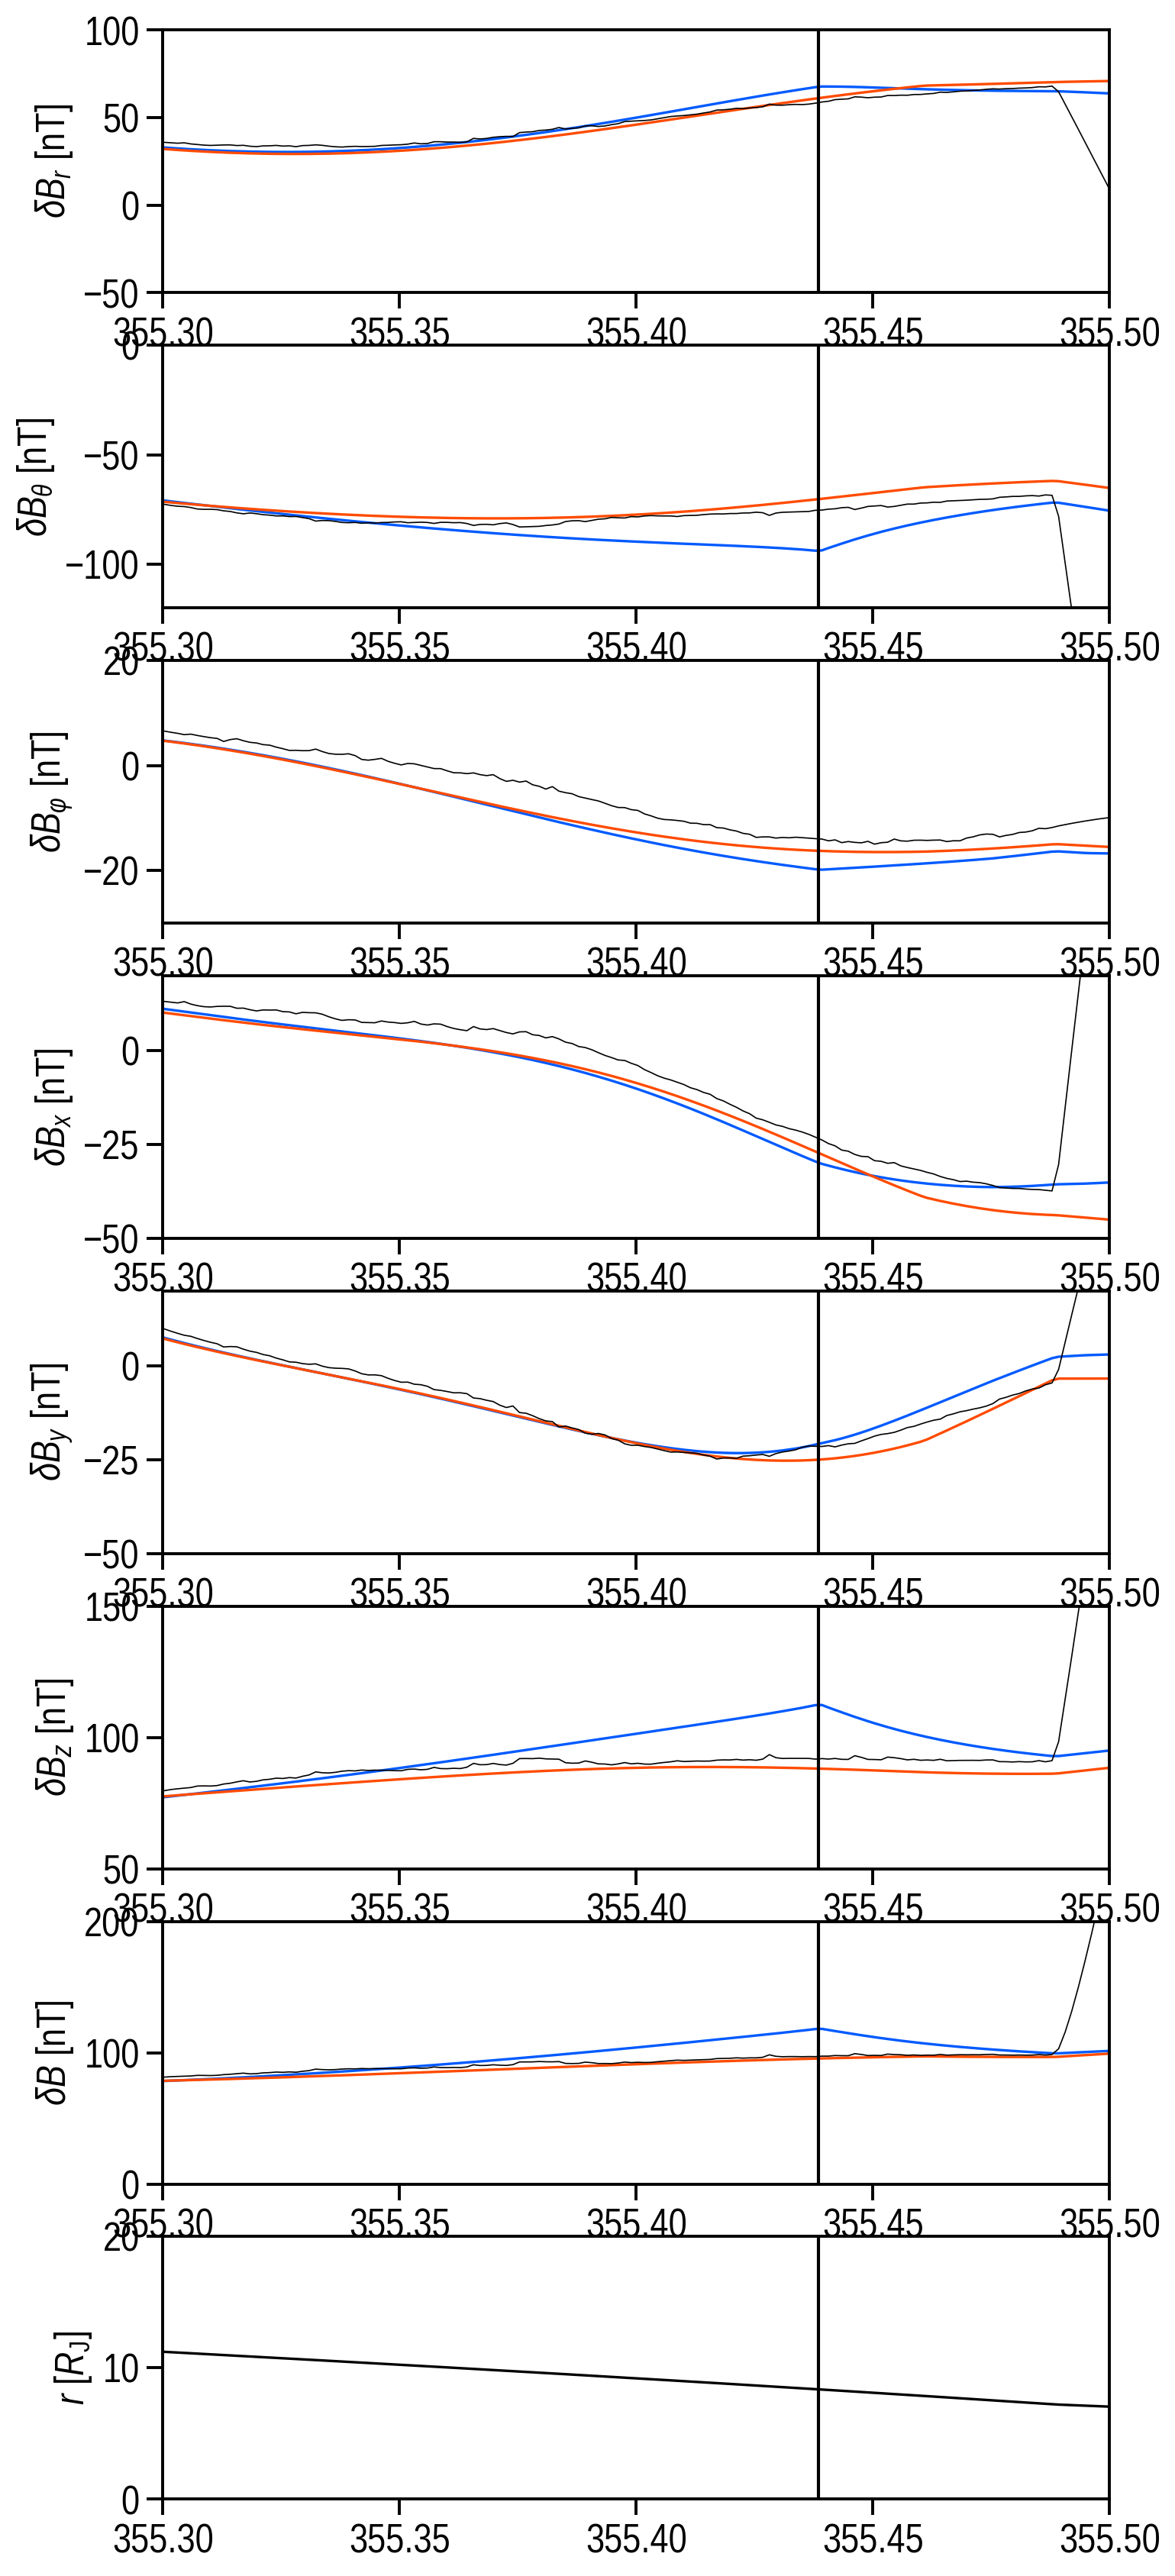

In [254]:
fig, ax = plt.subplots(8, 1, figsize=(8, 21.0), dpi=200)
for i in range(8):
    ax[i].set_xlim(355.3, 355.5)
ax[0].set_ylim(-50, 100)
ax[1].set_ylim(-120, 0)
ax[2].set_ylim(-30, 20)
ax[3].set_ylim(-50, 20)
ax[4].set_ylim(-50, 20)
ax[5].set_ylim(50, 150)
ax[6].set_ylim(0, 200)
ax[7].set_ylim(0, 20)
ax[0].set_ylabel(r'$\delta B_r$ [nT]')
ax[1].set_ylabel(r'$\delta B_{\theta}$ [nT]')
ax[2].set_ylabel(r'$\delta B_{\varphi}$ [nT]')
ax[3].set_ylabel(r'$\delta B_x$ [nT]')
ax[4].set_ylabel(r'$\delta B_y$ [nT]')
ax[5].set_ylabel(r'$\delta B_z$ [nT]')
ax[6].set_ylabel(r'$\delta B$ [nT]')
ax[7].set_ylabel(r'$r$ [$R_{\rm J}$]')
ax[0].plot(time_arr, dBr, color='k',
           linewidth=0.6, label='Observations', zorder=2.0)
ax[0].plot(time_arr, dBr1_pc, color=UC.blue,
           linewidth=1.2, label='Con2020', zorder=1.0)
ax[0].plot(time_arr, dBr2_pc, color=UC.red,
           linewidth=1.2, label='DoE', zorder=1.0)
ax[1].plot(time_arr, dBtheta, color='k',
           linewidth=0.6, label='Obs', zorder=2.0)
ax[1].plot(time_arr, dBtheta1_pc, color=UC.blue,
           linewidth=1.2, label='Con2020', zorder=1.0)
ax[1].plot(time_arr, dBtheta2_pc, color=UC.red,
           linewidth=1.2, label='DoE', zorder=1.0)
ax[2].plot(time_arr, dBphi, color='k',
           linewidth=0.6, label='Obs', zorder=2.0)
ax[2].plot(time_arr, dBphi1_pc, color=UC.blue,
           linewidth=1.2, label='Con2020', zorder=1.0)
ax[2].plot(time_arr, dBphi2_pc, color=UC.red,
           linewidth=1.2, label='DoE', zorder=1.0)
ax[3].plot(time_arr, dBx, color='k',
           linewidth=0.6, label='Obs', zorder=2.0)
ax[3].plot(time_arr, dBx1_pc, color=UC.blue,
           linewidth=1.2, label='Con2020', zorder=1.0)
ax[3].plot(time_arr, dBx2_pc, color=UC.red,
           linewidth=1.2, label='DoE', zorder=1.0)
ax[4].plot(time_arr, dBy, color='k',
           linewidth=0.6, label='Obs', zorder=2.0)
ax[4].plot(time_arr, dBy1_pc, color=UC.blue,
           linewidth=1.2, label='Con2020', zorder=1.0)
ax[4].plot(time_arr, dBy2_pc, color=UC.red,
           linewidth=1.2, label='DoE', zorder=1.0)
ax[5].plot(time_arr, dBz, color='k',
           linewidth=0.6, label='Obs', zorder=2.0)
ax[5].plot(time_arr, dBz1_pc, color=UC.blue,
           linewidth=1.2, label='Con2020', zorder=1.0)
ax[5].plot(time_arr, dBz2_pc, color=UC.red,
           linewidth=1.2, label='DoE', zorder=1.0)
ax[6].plot(time_arr,
           np.sqrt(dBx**2+dBy**2+dBz**2),
           color='k',
           linewidth=0.6, label='Obs', zorder=2.0)
ax[6].plot(time_arr,
           np.sqrt(dBx1_pc**2+dBy1_pc**2+dBz1_pc**2),
           color=UC.blue,
           linewidth=1.2, label='Con2020', zorder=1.0)
ax[6].plot(time_arr,
           np.sqrt(dBx2_pc**2+dBy2_pc**2+dBz2_pc**2),
           color=UC.red,
           linewidth=1.2, label='DoE', zorder=1.0)
ax[7].plot(time_arr, r_pc, color='k',
           linewidth=1.2, zorder=1.0)
for i in range(8):
    ax[i].axvline(x=355.4385,
                  color='k', zorder=1.0)

print(r_pc[np.argmin(abs(time_arr-355.4385))])
print(r_pc[np.argmin(abs(time_arr-355.4385))+1])

In [255]:
# RMSE（Root Mean Squared Error: 二乗平均平方根誤差）
print('Inbound')
print(math.sqrt(np.sum((dBr[:1065]-dBr1_pc[:1065])**2)/dBr[:1065].size))
print(math.sqrt(np.sum((dBr[:1065]-dBr2_pc[:1065])**2)/dBr[:1065].size))
print(
    math.sqrt(np.sum((dBtheta[:1065]-dBtheta1_pc[:1065])**2)/dBr[:1065].size))
print(
    math.sqrt(np.sum((dBtheta[:1065]-dBtheta2_pc[:1065])**2)/dBr[:1065].size))
print(math.sqrt(np.sum((dBphi[:1065]-dBphi1_pc[:1065])**2)/dBr[:1065].size))
print(math.sqrt(np.sum((dBphi[:1065]-dBphi2_pc[:1065])**2)/dBr[:1065].size))

print('Outbound')
print(math.sqrt(np.sum((dBr[1400:]-dBr1_pc[1400:])**2)/dBr[1400:].size))
print(math.sqrt(np.sum((dBr[1400:]-dBr2_pc[1400:])**2)/dBr[1400:].size))
print(
    math.sqrt(np.sum((dBtheta[1400:]-dBtheta1_pc[1400:])**2)/dBr[1400:].size))
print(
    math.sqrt(np.sum((dBtheta[1400:]-dBtheta2_pc[1400:])**2)/dBr[1400:].size))
print(math.sqrt(np.sum((dBphi[1400:]-dBphi1_pc[1400:])**2)/dBr[1400:].size))
print(math.sqrt(np.sum((dBphi[1400:]-dBphi2_pc[1400:])**2)/dBr[1400:].size))

Inbound
4.4162108131253
4.167876776202845
3.883922944374258
2.567501638687191
2.4491775503055835
2.1537822245458997
Outbound
3.1781030986711913
3.7383902008215135
0.8278407639757178
1.2562944753164655
1.386238511712457
1.3812535459923014


In [256]:
print(np.argsort(abs(r_pc-36.0)))

[2875 2874 2873 ... 1226 1224 1225]


In [257]:
print(r_pc[2875])

35.54019555421592


In [258]:
r_ticks = np.array([[29, time_arr[29]],
                    [28, time_arr[92]],
                    [27, time_arr[154]],
                    [26, time_arr[214]],
                    [25, time_arr[273]],
                    [24, time_arr[331]],
                    [23, time_arr[387]],
                    [22, time_arr[442]],
                    [21, time_arr[495]],
                    [20, time_arr[546]],
                    [19, time_arr[597]],
                    [18, time_arr[645]],
                    [17, time_arr[693]],
                    [16, time_arr[737]],
                    [15, time_arr[781]],
                    [14, time_arr[824]],
                    [13, time_arr[865]],
                    [12, time_arr[904]],
                    [11, time_arr[942]],
                    [10, time_arr[978]],
                    [9, time_arr[1013]],
                    [8, time_arr[1045]],
                    [8, time_arr[1410]],
                    [9, time_arr[1442]],
                    [10, time_arr[1476]],
                    [11, time_arr[1512]],
                    [12, time_arr[1550]],
                    [13, time_arr[1589]],
                    [14, time_arr[1630]],
                    [15, time_arr[1673]],
                    [16, time_arr[1717]],
                    [17, time_arr[1763]],
                    [18, time_arr[1810]],
                    [19, time_arr[1859]],
                    [20, time_arr[1909]],
                    [21, time_arr[1961]],
                    [22, time_arr[2014]],
                    [23, time_arr[2068]],
                    [24, time_arr[2124]],
                    [25, time_arr[2181]],
                    [26, time_arr[2240]],
                    [27, time_arr[2300]],
                    [28, time_arr[2362]],
                    [29, time_arr[2425]],
                    [30, time_arr[2490]],
                    [31, time_arr[2556]],
                    [32, time_arr[2624]],
                    [33, time_arr[2693]],
                    [34, time_arr[2763]],
                    [35, time_arr[2835]],])
print(r_ticks[1, :])

[ 28.         354.12951357]


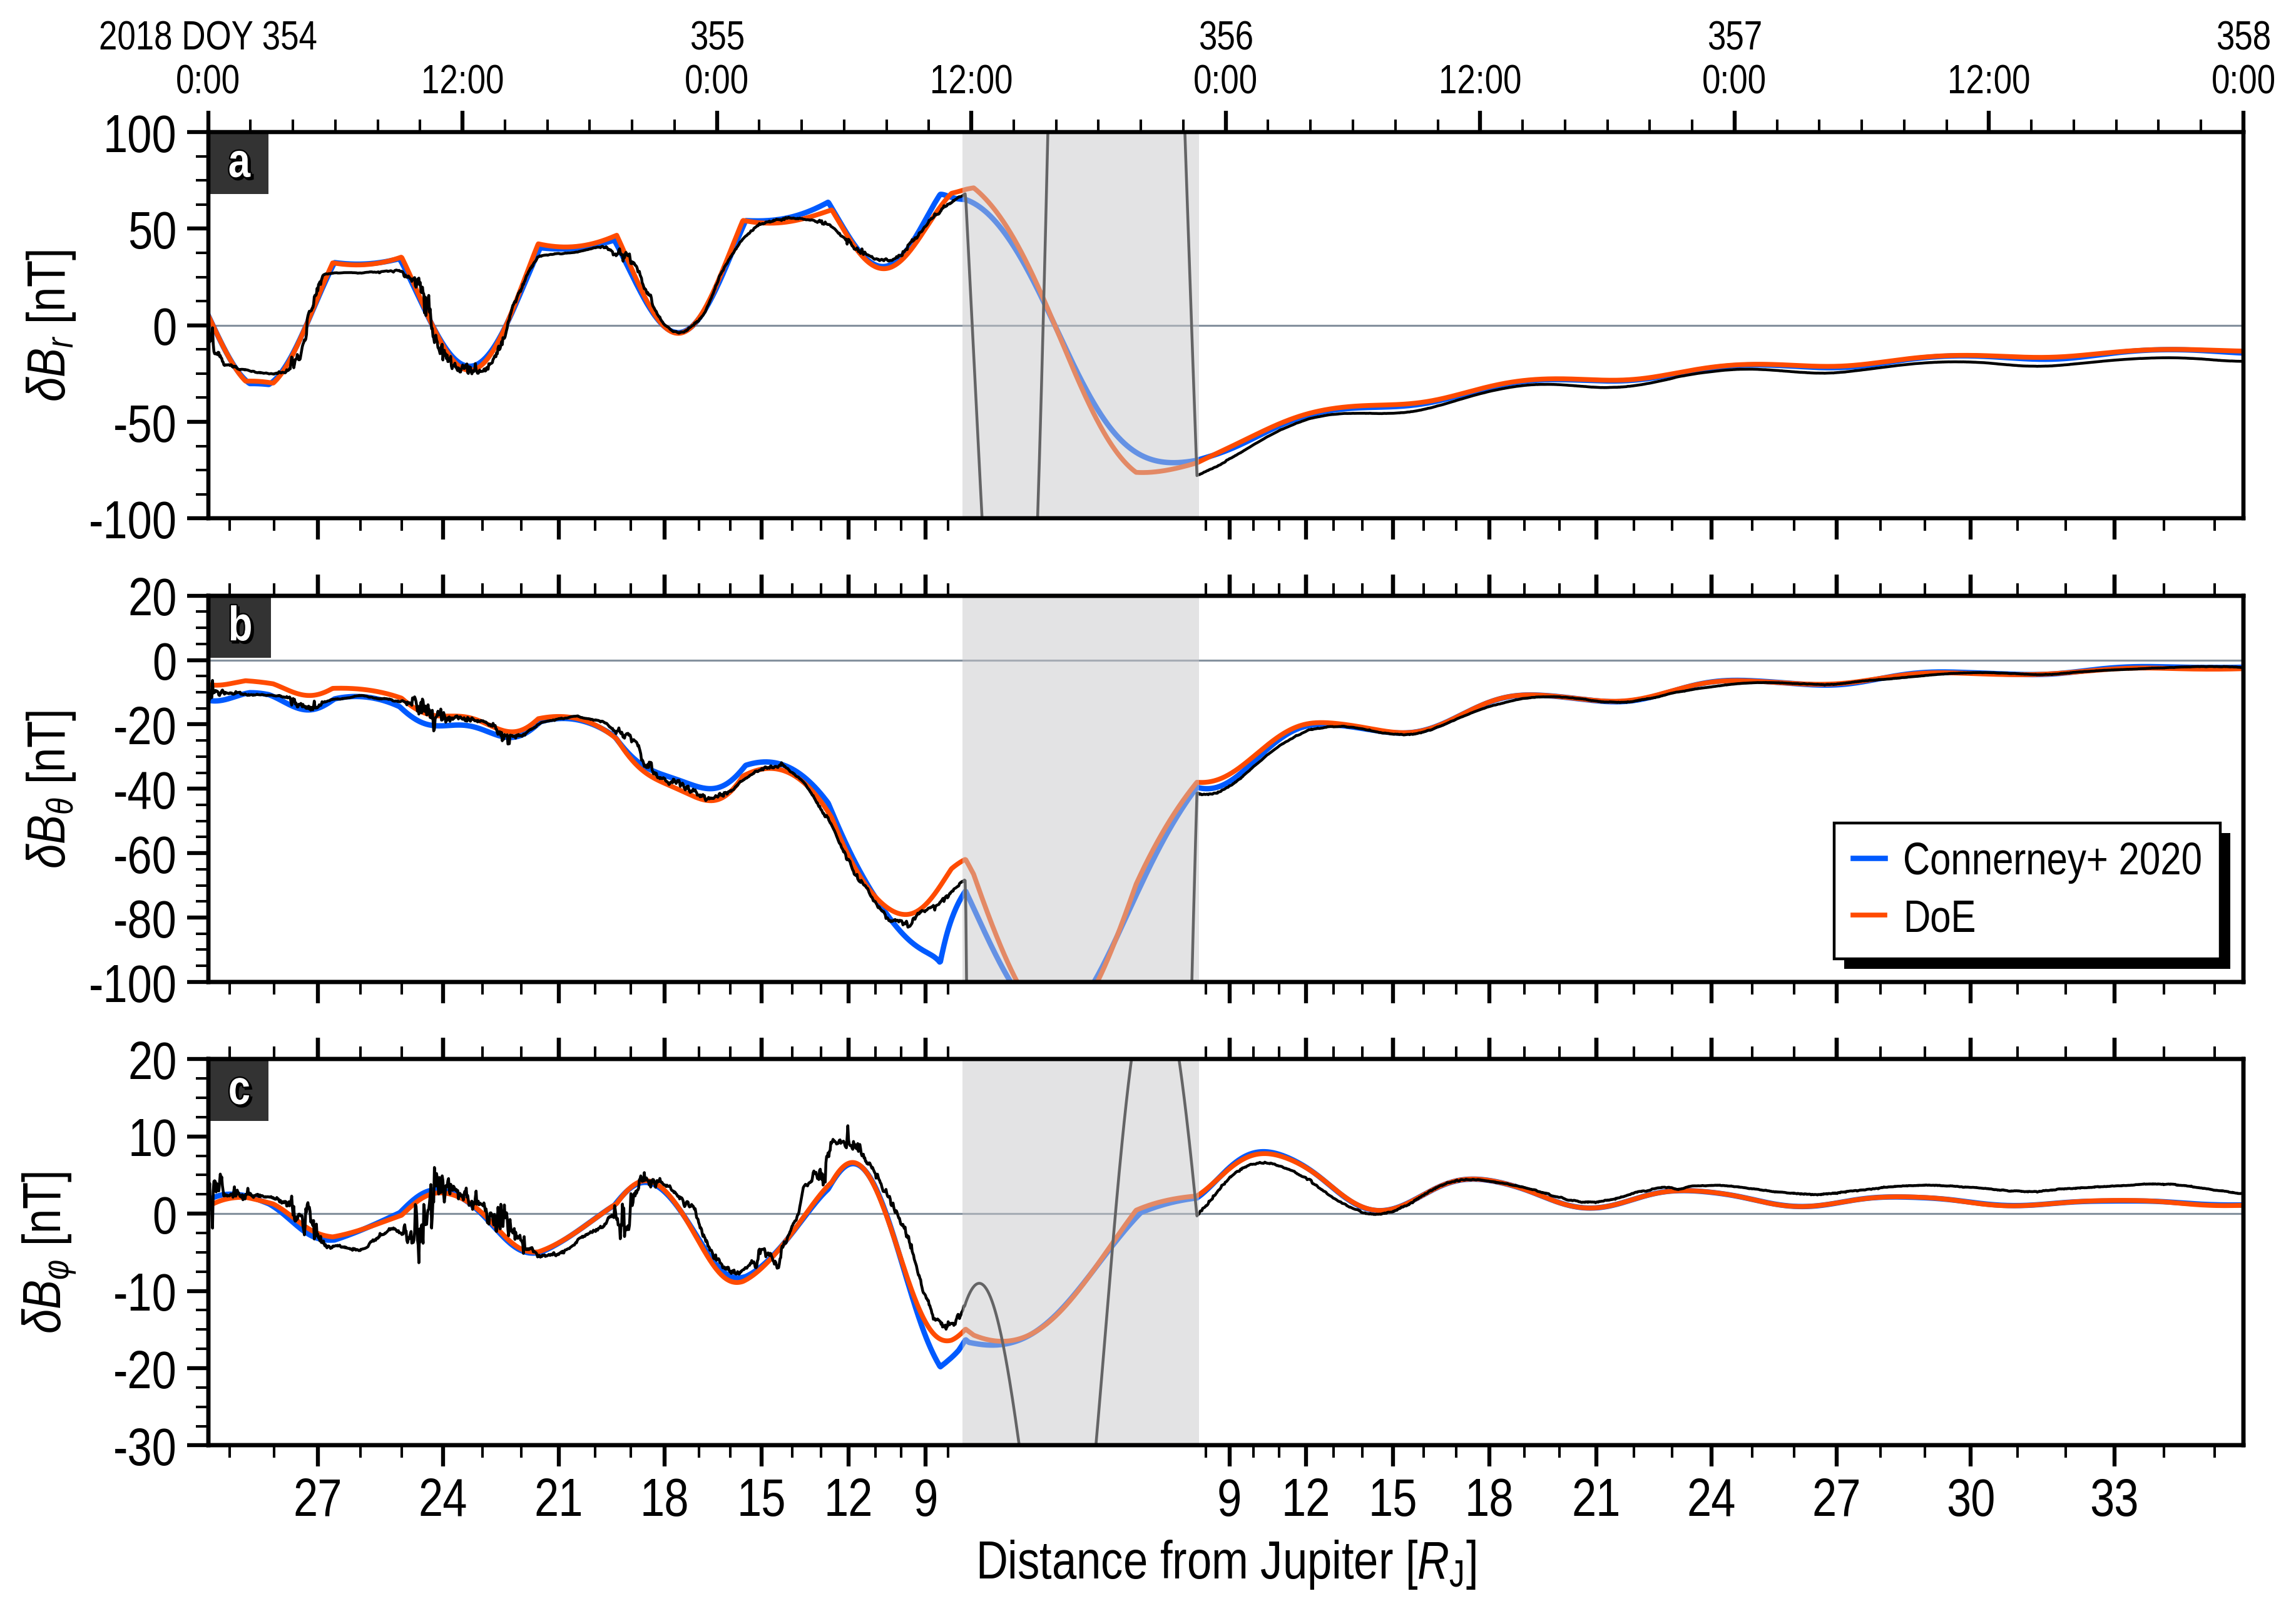

In [259]:
F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=3, figsize=(11.0, 7.5), dpi='XL')
F.hspace = 0.2
F.initialize()

xticks = r_ticks[2::3, 1]
xticklabels = r_ticks[2::3, 0].astype(int)

F.set_xaxis(label=r'Distance from Jupiter [$R_{\rm J}$]',
            min=354.0, max=358.0,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=None)
for i in range(3):
    F.ax[i].xaxis.set_minor_locator(FixedLocator(r_ticks[:, 1]))
for i in range(2):
    i += 1
    ax_upper = F.ax[i].twiny()
    ax_upper.set_xlim(354.0, 358.0)
    ax_upper.set_xticks(xticks)
    ax_upper.xaxis.set_minor_locator(FixedLocator(r_ticks[:, 1]))
    ax_upper.tick_params(labeltop=False)

F.set_yaxis(ax_idx=0,
            label=r'$\delta B_{r}$ [nT]',
            min=-100, max=100,
            ticks=np.linspace(-100, 100, 5),
            ticklabels=np.linspace(-100, 100, 5, dtype=int),
            minor_num=4)
F.set_yaxis(ax_idx=1,
            label=r'$\delta B_{\theta}$ [nT]',
            min=-100, max=20,
            ticks=np.linspace(-100, 20, 7),
            ticklabels=np.linspace(-100, 20, 7, dtype=int),
            minor_num=4)
F.set_yaxis(ax_idx=2,
            label=r'$\delta B_{\varphi}$ [nT]',
            min=-30, max=20,
            ticks=np.linspace(-30, 20, 6),
            ticklabels=np.linspace(-30, 20, 6, dtype=int),
            minor_num=4)
F.ax[0].plot(time_arr, dBr, color='k',
             linewidth=1.0, label='Observations', zorder=2.0)
F.ax[0].plot(time_arr, dBr1_pc, color=UC.blue,
             linewidth=1.9, label='Connerney+ 2020', zorder=1.0)
F.ax[0].plot(time_arr, dBr2_pc, color=UC.red,
             linewidth=1.7, label='This study', zorder=1.0)
F.ax[1].plot(time_arr, dBtheta, color='k',
             linewidth=1.0, zorder=2.0)
F.ax[1].plot(time_arr, dBtheta1_pc, color=UC.blue,
             linewidth=1.9, label='Connerney+ 2020', zorder=1.0)
F.ax[1].plot(time_arr, dBtheta2_pc, color=UC.red,
             linewidth=1.7, label='DoE', zorder=1.0)
F.ax[2].plot(time_arr, dBphi, color='k',
             linewidth=1.0, label='Observations', zorder=2.0)
F.ax[2].plot(time_arr, dBphi1_pc, color=UC.blue,
             linewidth=1.9, label='Connerney+ 2020', zorder=1.0)
F.ax[2].plot(time_arr, dBphi2_pc, color=UC.red,
             linewidth=1.7, label='DoE', zorder=1.0)

# Shades near Jupiter
for i in range(F.nrows):
    F.ax[i].axvspan(time_arr[1065], time_arr[1400],
                    fc=UC.lightgray, ec=None,
                    alpha=0.5, zorder=2.5)

# y = 0 line
for i in range(F.nrows):
    F.ax[i].axhline(y=0.0, color=UC.gray, linewidth=0.7, zorder=0.9)

# Time axis
timeax = F.ax[0].twiny()
timeax.set_xlim(354.0, 358.0)
timeax.set_xticks([354.0, 354.5,
                   355.0, 355.5, 356.0, 356.5,
                   357.0, 357.5, 358.0])
timeax.set_xticklabels(['2018 DOY 354\n0:00', '12:00',
                        '355\n0:00', '12:00', '356\n0:00', '12:00',
                        '357\n0:00', '12:00', '358\n0:00'], fontsize=F.fontsize*0.75)
timeax.xaxis.set_minor_locator(ptick.AutoMinorLocator(6))

legend = F.legend(ax_idx=1,
                  ncol=1, markerscale=1.0,
                  loc='lower right',
                  handlelength=0.7,
                  textcolor=False,
                  fontsize_scale=0.85,
                  handletextpad=0.4)
legend_shadow(legend=legend, fig=F.fig, ax=F.ax[0], d=0.7)

# PJ19のデータを読み込む

In [260]:
date_list = ['2019DOY094', '2019DOY095',
             '2019DOY096', '2019DOY097',]
time_list = []
Bx_pc = []
By_pc = []
Bz_pc = []
rx_pc = []
ry_pc = []
rz_pc = []
for i in range(len(date_list)):
    dir = '/Users/shin/Documents/Research/Juno/Mag/Codes/data/R3_' + \
        date_list[i]+'/'
    file_date = date_list[i][0:4]+date_list[i][-3:]
    time_list += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_time.txt').tolist()
    Bx_pc += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_Bx.txt').tolist()
    By_pc += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_By.txt').tolist()
    Bz_pc += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_Bz.txt').tolist()
    rx_pc += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_rx.txt').tolist()
    ry_pc += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_ry.txt').tolist()
    rz_pc += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_rz.txt').tolist()

time_arr = np.array(time_list)
Bx_pc = np.array(Bx_pc)
By_pc = np.array(By_pc)
Bz_pc = np.array(Bz_pc)
rx_pc = np.array(rx_pc)/71492.0
ry_pc = np.array(ry_pc)/71492.0
rz_pc = np.array(rz_pc)/71492.0

In [261]:
np.where(np.sqrt(Bx_pc**2+By_pc**2+Bz_pc**2) > 1600.0)

(array([1656, 1657, 1658, 1659, 1970, 1971, 1972, 1973, 1974, 1975, 1976,
        1977, 1978, 1979, 1980, 1981, 1982, 1983]),)

In [262]:
# 座標
r_pc = np.sqrt(rx_pc**2+ry_pc**2+rz_pc**2)
cos_phi = rx_pc/r_pc
sin_phi = ry_pc/r_pc
cos_theta = rz_pc/r_pc
sin_theta = np.sqrt(rx_pc**2+ry_pc**2)/r_pc
print('Distance [RJ]:', r_pc[0], r_pc[-1])

# Internal field
Bx0_pc = np.zeros(time_arr.size)
By0_pc = np.zeros(time_arr.size)
Bz0_pc = np.zeros(time_arr.size)
for i in range(time_arr.size):
    Bx0_pc[i], By0_pc[i], Bz0_pc[i] = jm.Internal.Field(rx_pc[i],
                                                        ry_pc[i],
                                                        rz_pc[i])  # [nT]
dBx = Bx_pc - Bx0_pc
dBy = By_pc - By0_pc
dBz = Bz_pc - Bz0_pc
dBr = dBx*sin_theta*cos_phi + dBy*sin_theta*sin_phi + dBz*cos_theta
dBtheta = dBx*cos_theta*cos_phi + dBy*cos_theta*sin_phi - dBz*sin_theta
dBphi = -dBx*sin_phi + dBy*cos_phi

# Con2020 original value
jm.Con2020.Config(mu_i=con20_mu_i_tot[np.where(con20_pj_idx == 19)])
dBx1_pc = np.zeros(time_arr.size)
dBy1_pc = np.zeros(time_arr.size)
dBz1_pc = np.zeros(time_arr.size)
for i in range(time_arr.size):
    dBx1_pc[i], dBy1_pc[i], dBz1_pc[i] = jm.Con2020.Field(rx_pc[i],
                                                          ry_pc[i],
                                                          rz_pc[i])  # [nT]
dBr1_pc = dBx1_pc*sin_theta*cos_phi + dBy1_pc * \
    sin_theta*sin_phi + dBz1_pc*cos_theta
dBtheta1_pc = dBx1_pc*cos_theta*cos_phi + \
    dBy1_pc*cos_theta*sin_phi - dBz1_pc*sin_theta
dBphi1_pc = -dBx1_pc*sin_phi + dBy1_pc*cos_phi

Distance [RJ]: 37.630682485270626 26.950306498547732


In [303]:
# DoE model
csfield = CSField()
csfield.config(
    I_rho=16.7,
    I_phi=1.4E-4,
    D=3.0,
    c=13.6*math.sqrt(2),    # 15.0 / 13.9
    d=25.0*math.sqrt(2),    # 24.8 / 25.0
)

dBx2_pc = np.zeros(time_arr.size)
dBy2_pc = np.zeros(time_arr.size)
dBz2_pc = np.zeros(time_arr.size)
for i in range(time_arr.size):
    dBx2_pc[i], dBy2_pc[i], dBz2_pc[i] = csfield.magnetic_field(rx_pc[i],
                                                                ry_pc[i],
                                                                rz_pc[i])  # [T]
dBx2_pc *= 1E+9    # [nT]
dBy2_pc *= 1E+9    # [nT]
dBz2_pc *= 1E+9    # [nT]
dBr2_pc = dBx2_pc*sin_theta*cos_phi + dBy2_pc * \
    sin_theta*sin_phi + dBz2_pc*cos_theta
dBtheta2_pc = dBx2_pc*cos_theta*cos_phi + \
    dBy2_pc*cos_theta*sin_phi - dBz2_pc*sin_theta
dBphi2_pc = -dBx2_pc*sin_phi + dBy2_pc*cos_phi

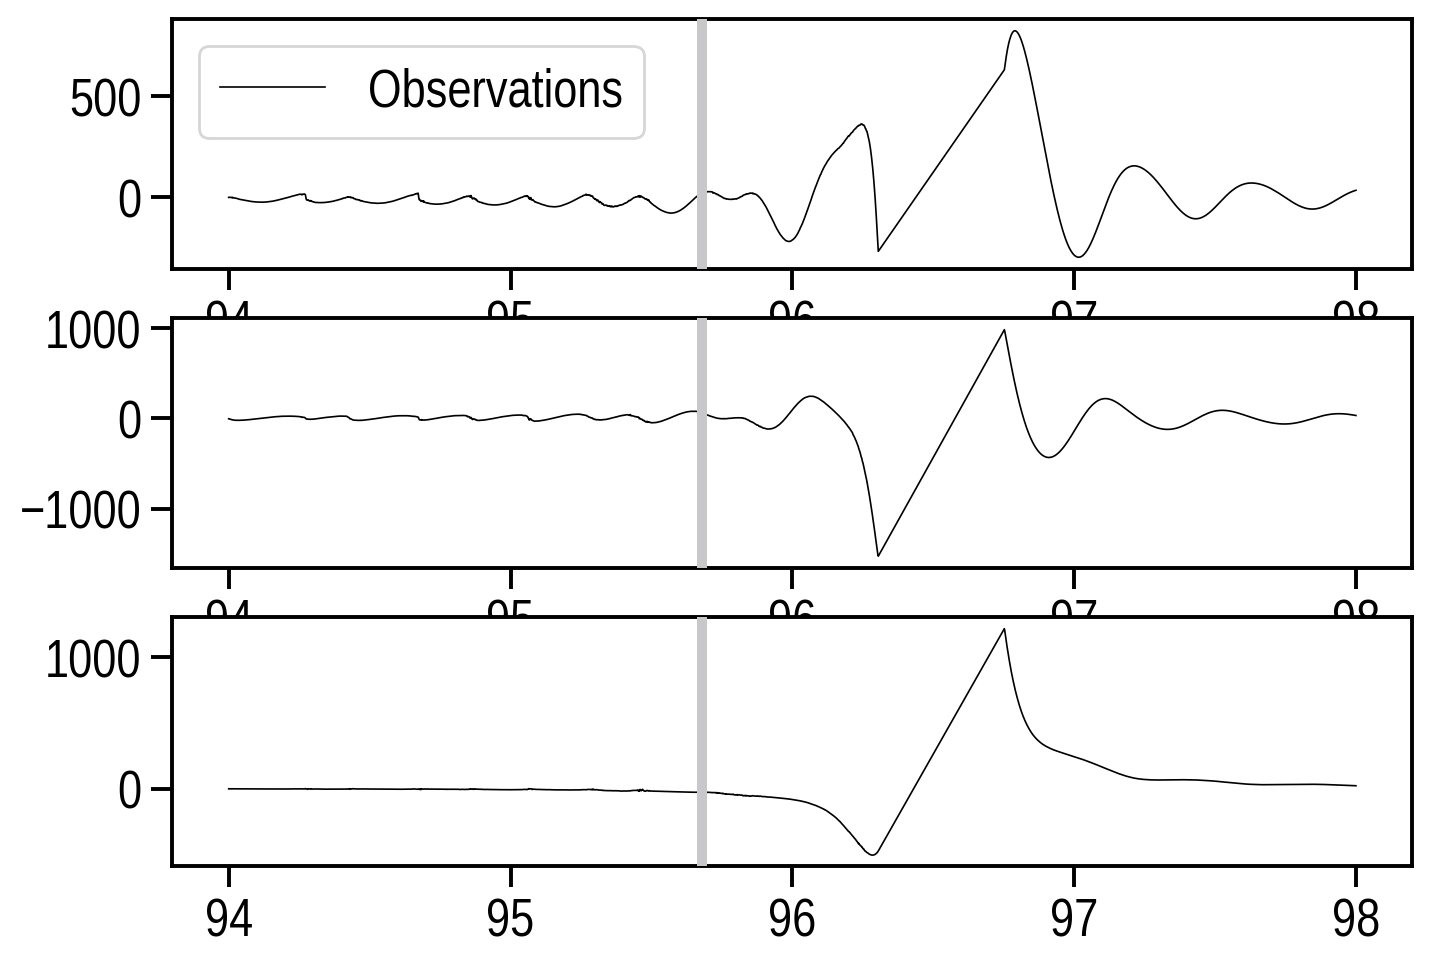

In [304]:
fig, ax = plt.subplots(3, 1, figsize=(8, 5.5), dpi=200)
ax[0].plot(time_arr, Bx_pc, color='k',
           linewidth=0.6, label='Observations', zorder=2.0)
ax[1].plot(time_arr, By_pc, color='k',
           linewidth=0.6, label='Obs', zorder=2.0)
ax[2].plot(time_arr, Bz_pc, color='k',
           linewidth=0.6, label='Obs', zorder=2.0)
ax[0].legend()
for i in range(3):
    ax[i].axvspan(xmin=time_arr[1195], xmax=time_arr[1220],
                  facecolor=UC.lightgray, zorder=3)

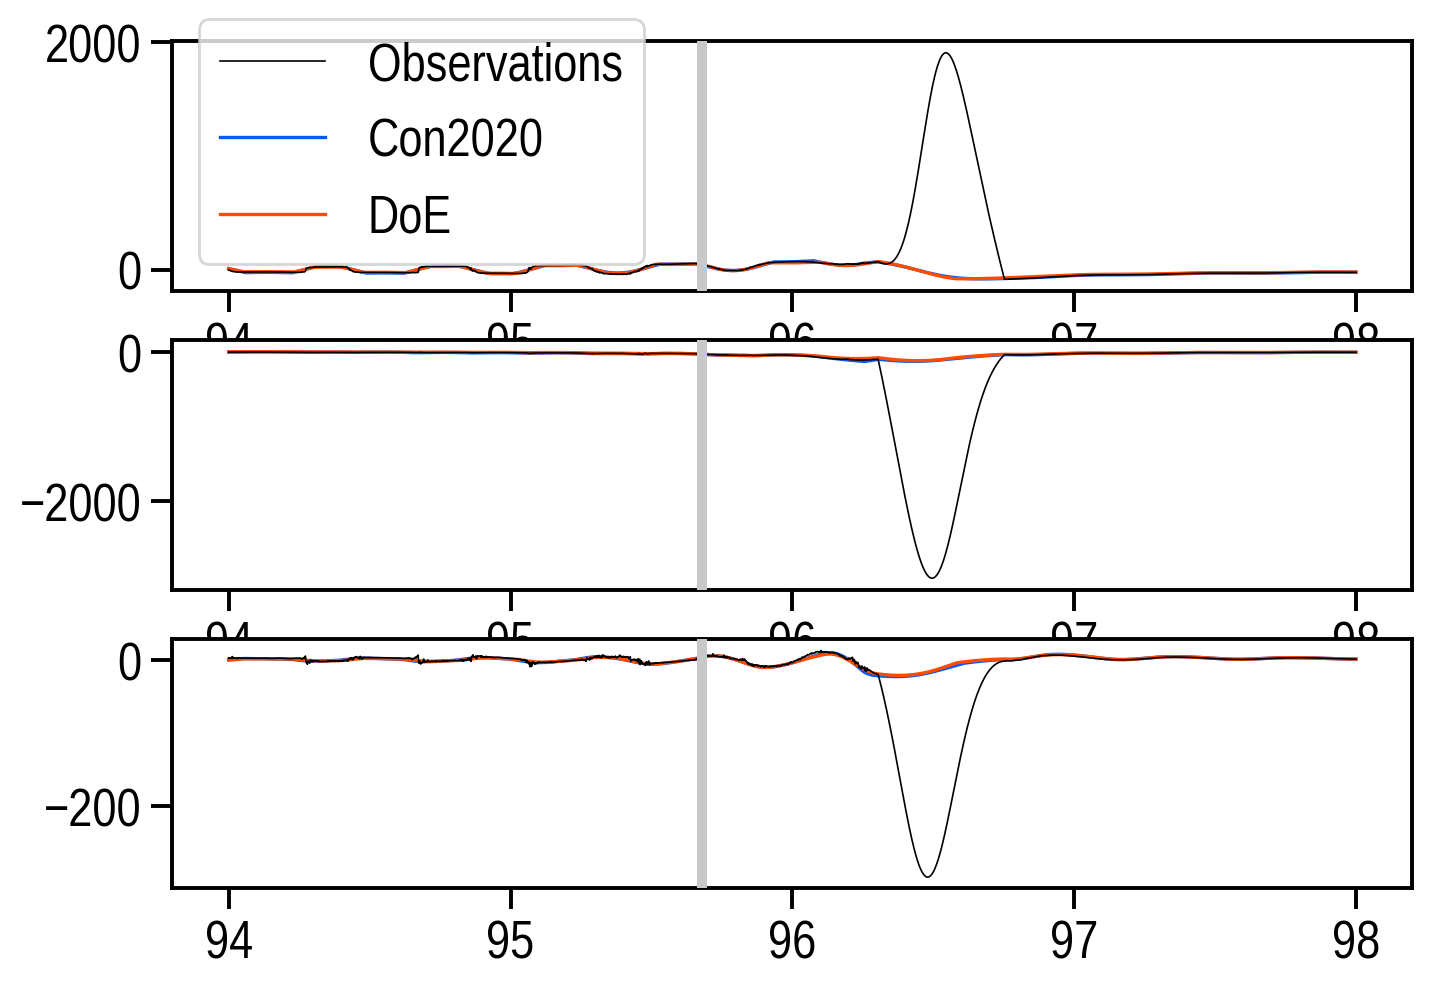

In [305]:
fig, ax = plt.subplots(3, 1, figsize=(8, 5.5), dpi=200)
ax[0].plot(time_arr, dBr, color='k',
           linewidth=0.6, label='Observations', zorder=2.0)
ax[0].plot(time_arr, dBr1_pc, color=UC.blue,
           linewidth=1.2, label='Con2020', zorder=1.0)
ax[0].plot(time_arr, dBr2_pc, color=UC.red,
           linewidth=1.2, label='DoE', zorder=1.0)
ax[1].plot(time_arr, dBtheta, color='k',
           linewidth=0.6, label='Obs', zorder=2.0)
ax[1].plot(time_arr, dBtheta1_pc, color=UC.blue,
           linewidth=1.2, label='Con2020', zorder=1.0)
ax[1].plot(time_arr, dBtheta2_pc, color=UC.red,
           linewidth=1.2, label='DoE', zorder=1.0)
ax[2].plot(time_arr, dBphi, color='k',
           linewidth=0.6, label='Obs', zorder=2.0)
ax[2].plot(time_arr, dBphi1_pc, color=UC.blue,
           linewidth=1.2, label='Con2020', zorder=1.0)
ax[2].plot(time_arr, dBphi2_pc, color=UC.red,
           linewidth=1.2, label='DoE', zorder=1.0)
ax[0].legend()
for i in range(3):
    ax[i].axvspan(xmin=time_arr[1195], xmax=time_arr[1220],
                  facecolor=UC.lightgray, zorder=3)

In [306]:
# RMSE（Root Mean Squared Error: 二乗平均平方根誤差）
print('Inbound')
print(
    math.sqrt(np.sum((dBr[:1620]-dBr1_pc[:1620])**2)/dBr[:1620].size))
print(
    math.sqrt(np.sum((dBr[:1620]-dBr2_pc[:1620])**2)/dBr[:1620].size))
print(
    math.sqrt(np.sum((dBtheta[:1620]-dBtheta1_pc[:1620])**2)/dBr[:1620].size))
print(
    math.sqrt(np.sum((dBtheta[:1620]-dBtheta2_pc[:1620])**2)/dBr[:1620].size))
print(
    math.sqrt(np.sum((dBphi[:1620]-dBphi1_pc[:1620])**2)/dBr[:1620].size))
print(
    math.sqrt(np.sum((dBphi[:1620]-dBphi2_pc[:1620])**2)/dBr[:1620].size))

print('Outbound')
print(math.sqrt(np.sum((dBr[1990:]-dBr1_pc[1990:])**2)/dBr[1990:].size))
print(math.sqrt(np.sum((dBr[1990:]-dBr2_pc[1990:])**2)/dBr[1990:].size))
print(
    math.sqrt(np.sum((dBtheta[1990:]-dBtheta1_pc[1990:])**2)/dBr[1990:].size))
print(
    math.sqrt(np.sum((dBtheta[1990:]-dBtheta2_pc[1990:])**2)/dBr[1990:].size))
print(math.sqrt(np.sum((dBphi[1990:]-dBphi1_pc[1990:])**2)/dBr[1990:].size))
print(math.sqrt(np.sum((dBphi[1990:]-dBphi2_pc[1990:])**2)/dBr[1990:].size))

Inbound
7.574080258099873
6.979440369631596
3.32992479176508
6.080435137225601
1.790969247583267
1.806470995721597
Outbound
1.647703789126065
5.7010689440766065
1.0318111441071016
2.5417417914013347
0.6899863699431779
0.7034318178287507


In [307]:
print(np.argsort(abs(r_pc-8.0)))

[1988 1622 1623 ...    2    1    0]


In [308]:
print(r_pc[1193])

18.620005295513327


In [309]:
r_ticks = np.array([[37, time_arr[48]],
                    [36, time_arr[123]],
                    [35, time_arr[197]],
                    [34, time_arr[269]],
                    [33, time_arr[339]],
                    [32, time_arr[408]],
                    [31, time_arr[476]],
                    [30, time_arr[542]],
                    [29, time_arr[607]],
                    [28, time_arr[670]],
                    [27, time_arr[732]],
                    [26, time_arr[792]],
                    [25, time_arr[851]],
                    [24, time_arr[909]],
                    [23, time_arr[965]],
                    [22, time_arr[1019]],
                    [21, time_arr[1072]],
                    [20, time_arr[1124]],
                    [19, time_arr[1174]],
                    [18, time_arr[1223]],
                    [17, time_arr[1270]],
                    [16, time_arr[1316]],
                    [15, time_arr[1360]],
                    [14, time_arr[1403]],
                    [13, time_arr[1442]],
                    [12, time_arr[1482]],
                    [11, time_arr[1519]],
                    [10, time_arr[1556]],
                    [9, time_arr[1590]],
                    [8, time_arr[1622]],
                    [8, time_arr[1988]],
                    [9, time_arr[2020]],
                    [10, time_arr[2055]],
                    [11, time_arr[2091]],
                    [12, time_arr[2128]],
                    [13, time_arr[2167]],
                    [14, time_arr[2208]],
                    [15, time_arr[2250]],
                    [16, time_arr[2295]],
                    [17, time_arr[2340]],
                    [18, time_arr[2388]],
                    [19, time_arr[2436]],
                    [20, time_arr[2486]],
                    [21, time_arr[2538]],
                    [22, time_arr[2591]],
                    [23, time_arr[2646]],
                    [24, time_arr[2702]],
                    [25, time_arr[2760]],
                    [26, time_arr[2819]],])
print(r_ticks[1, :])

[36.         94.17086221]


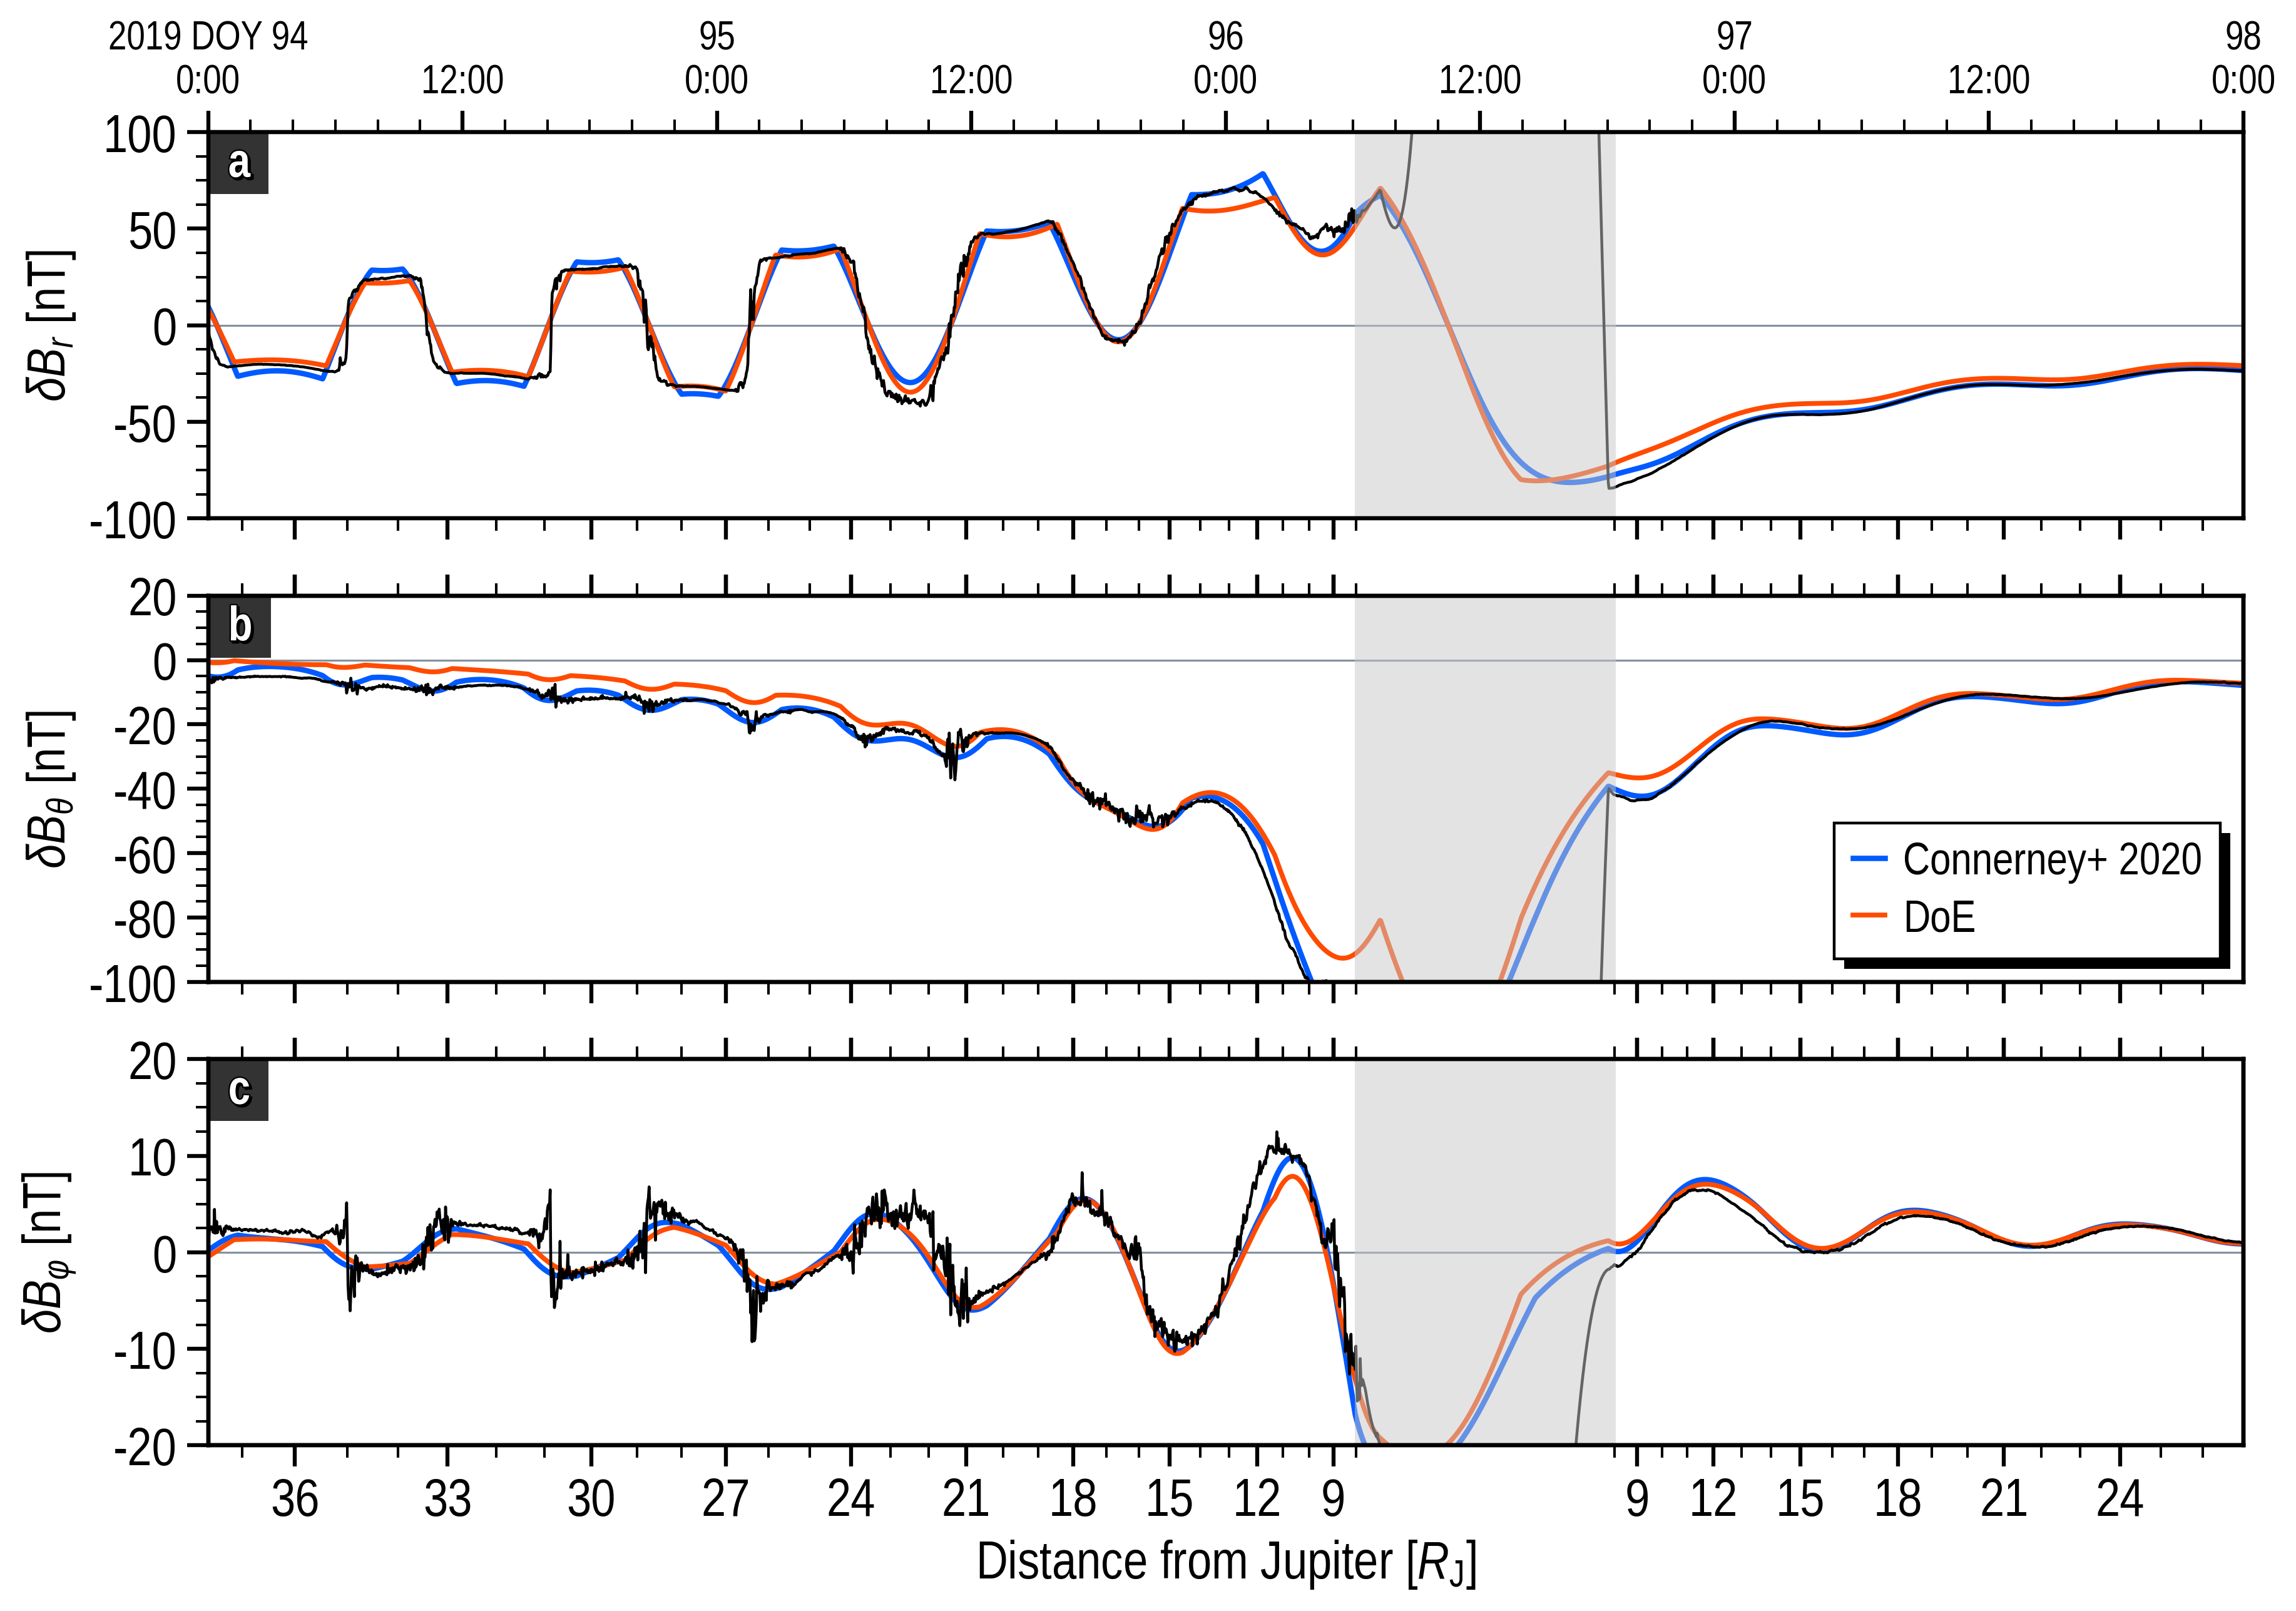

In [310]:
F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=3, figsize=(11.0, 7.5), dpi='XL')
F.hspace = 0.2
F.initialize()

xticks = r_ticks[1::3, 1]
xticklabels = r_ticks[1::3, 0].astype(int)

F.set_xaxis(label=r'Distance from Jupiter [$R_{\rm J}$]',
            min=94.0, max=98.0,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=None)
for i in range(3):
    F.ax[i].xaxis.set_minor_locator(FixedLocator(r_ticks[:, 1]))
for i in range(2):
    i += 1
    ax_upper = F.ax[i].twiny()
    ax_upper.set_xlim(94.0, 98.0)
    ax_upper.set_xticks(xticks)
    ax_upper.xaxis.set_minor_locator(FixedLocator(r_ticks[:, 1]))
    ax_upper.tick_params(labeltop=False)

F.set_yaxis(ax_idx=0,
            label=r'$\delta B_{r}$ [nT]',
            min=-100, max=100,
            ticks=np.linspace(-100, 100, 5),
            ticklabels=np.linspace(-100, 100, 5, dtype=int),
            minor_num=4)
F.set_yaxis(ax_idx=1,
            label=r'$\delta B_{\theta}$ [nT]',
            min=-100, max=20,
            ticks=np.linspace(-100, 20, 7),
            ticklabels=np.linspace(-100, 20, 7, dtype=int),
            minor_num=4)
F.set_yaxis(ax_idx=2,
            label=r'$\delta B_{\varphi}$ [nT]',
            min=-20, max=20,
            ticks=np.linspace(-20, 20, 5),
            ticklabels=np.linspace(-20, 20, 5, dtype=int),
            minor_num=4)
F.ax[0].plot(time_arr, dBr, color='k',
             linewidth=1.0, label='Observations', zorder=2.0)
F.ax[0].plot(time_arr, dBr1_pc, color=UC.blue,
             linewidth=1.9, label='Connerney+ 2020', zorder=1.0)
F.ax[0].plot(time_arr, dBr2_pc, color=UC.red,
             linewidth=1.7, label='DoE', zorder=1.0)
F.ax[1].plot(time_arr, dBtheta, color='k',
             linewidth=1.0, zorder=2.0)
F.ax[1].plot(time_arr, dBtheta1_pc, color=UC.blue,
             linewidth=1.9, label='Connerney+ 2020', zorder=1.0)
F.ax[1].plot(time_arr, dBtheta2_pc, color=UC.red,
             linewidth=1.7, label='DoE', zorder=1.0)
F.ax[2].plot(time_arr, dBphi, color='k',
             linewidth=1.0, label='Observations', zorder=2.0)
F.ax[2].plot(time_arr, dBphi1_pc, color=UC.blue,
             linewidth=1.9, label='Connerney+ 2020', zorder=1.0)
F.ax[2].plot(time_arr, dBphi2_pc, color=UC.red,
             linewidth=1.7, label='DoE', zorder=1.0)

# Shades near Jupiter
for i in range(F.nrows):
    F.ax[i].axvspan(time_arr[1620], time_arr[1990],
                    fc=UC.lightgray, ec=None,
                    alpha=0.5, zorder=2.5)

# y = 0 line
for i in range(F.nrows):
    F.ax[i].axhline(y=0.0, color=UC.gray, linewidth=0.7, zorder=0.9)

# Time axis
timeax = F.ax[0].twiny()
timeax.set_xlim(94.0, 98.0)
timeax.set_xticks([94.0, 94.5, 95.0, 95.5,
                   96.0, 96.5, 97.0, 97.5,
                   98.0,])
timeax.set_xticklabels(['2019 DOY 94\n0:00', '12:00',
                        '95\n0:00', '12:00', '96\n0:00', '12:00',
                        '97\n0:00', '12:00', '98\n0:00',], fontsize=F.fontsize*0.75)
timeax.xaxis.set_minor_locator(ptick.AutoMinorLocator(6))

legend = F.legend(ax_idx=1,
                  ncol=1, markerscale=1.0,
                  loc='lower right',
                  handlelength=0.7,
                  textcolor=False,
                  fontsize_scale=0.85,
                  handletextpad=0.4)
legend_shadow(legend=legend, fig=F.fig, ax=F.ax[0], d=0.7)

# PJ21のデータを読み込む

In [311]:
date_list = ['2019DOY200',
             '2019DOY201', '2019DOY202',
             '2019DOY203']
time_list = []
Bx_pc = []
By_pc = []
Bz_pc = []
rx_pc = []
ry_pc = []
rz_pc = []
for i in range(len(date_list)):
    dir = '/Users/shin/Documents/Research/Juno/Mag/Codes/data/R3_' + \
        date_list[i]+'/'
    file_date = date_list[i][0:4]+date_list[i][-3:]
    time_list += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_time.txt').tolist()
    Bx_pc += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_Bx.txt').tolist()
    By_pc += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_By.txt').tolist()
    Bz_pc += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_Bz.txt').tolist()
    rx_pc += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_rx.txt').tolist()
    ry_pc += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_ry.txt').tolist()
    rz_pc += np.loadtxt(dir+'jmag_'+file_date+'pc_2min_rz.txt').tolist()

time_arr = np.array(time_list)
Bx_pc = np.array(Bx_pc)
By_pc = np.array(By_pc)
Bz_pc = np.array(Bz_pc)
rx_pc = np.array(rx_pc)/71492.0
ry_pc = np.array(ry_pc)/71492.0
rz_pc = np.array(rz_pc)/71492.0

In [312]:
np.where(np.sqrt(Bx_pc**2+By_pc**2+Bz_pc**2) > 1600.0)

(array([1417, 1418]),)

In [313]:
# 座標
r_pc = np.sqrt(rx_pc**2+ry_pc**2+rz_pc**2)
cos_phi = rx_pc/r_pc
sin_phi = ry_pc/r_pc
cos_theta = rz_pc/r_pc
sin_theta = np.sqrt(rx_pc**2+ry_pc**2)/r_pc
print('Distance [RJ]:', r_pc[0], r_pc[-1])

# Internal field
Bx0_pc = np.zeros(time_arr.size)
By0_pc = np.zeros(time_arr.size)
Bz0_pc = np.zeros(time_arr.size)
for i in range(time_arr.size):
    Bx0_pc[i], By0_pc[i], Bz0_pc[i] = jm.Internal.Field(rx_pc[i],
                                                        ry_pc[i],
                                                        rz_pc[i])  # [nT]
dBx = Bx_pc - Bx0_pc
dBy = By_pc - By0_pc
dBz = Bz_pc - Bz0_pc
dBr = dBx*sin_theta*cos_phi + dBy*sin_theta*sin_phi + dBz*cos_theta
dBtheta = dBx*cos_theta*cos_phi + dBy*cos_theta*sin_phi - dBz*sin_theta
dBphi = -dBx*sin_phi + dBy*cos_phi

# Con2020 original value
jm.Con2020.Config(mu_i=con20_mu_i_tot[np.where(con20_pj_idx == 21)])
dBx1_pc = np.zeros(time_arr.size)
dBy1_pc = np.zeros(time_arr.size)
dBz1_pc = np.zeros(time_arr.size)
for i in range(time_arr.size):
    dBx1_pc[i], dBy1_pc[i], dBz1_pc[i] = jm.Con2020.Field(rx_pc[i],
                                                          ry_pc[i],
                                                          rz_pc[i])  # [nT]
dBr1_pc = dBx1_pc*sin_theta*cos_phi + dBy1_pc * \
    sin_theta*sin_phi + dBz1_pc*cos_theta
dBtheta1_pc = dBx1_pc*cos_theta*cos_phi + \
    dBy1_pc*cos_theta*sin_phi - dBz1_pc*sin_theta
dBphi1_pc = -dBx1_pc*sin_phi + dBy1_pc*cos_phi

Distance [RJ]: 34.268311186948274 30.769408353792578


In [330]:
# DoE model
csfield = CSField()
csfield.config(
    I_rho=16.7,
    I_phi=1.3E-4,
    D=3.5,
    c=13.6*math.sqrt(2),    # 15.0 / 13.9
    d=25.0*math.sqrt(2),    # 24.8 / 25.0
)

dBx2_pc = np.zeros(time_arr.size)
dBy2_pc = np.zeros(time_arr.size)
dBz2_pc = np.zeros(time_arr.size)
for i in range(time_arr.size):
    dBx2_pc[i], dBy2_pc[i], dBz2_pc[i] = csfield.magnetic_field(rx_pc[i],
                                                                ry_pc[i],
                                                                rz_pc[i])  # [T]
dBx2_pc *= 1E+9    # [nT]
dBy2_pc *= 1E+9    # [nT]
dBz2_pc *= 1E+9    # [nT]
dBr2_pc = dBx2_pc*sin_theta*cos_phi + dBy2_pc * \
    sin_theta*sin_phi + dBz2_pc*cos_theta
dBtheta2_pc = dBx2_pc*cos_theta*cos_phi + \
    dBy2_pc*cos_theta*sin_phi - dBz2_pc*sin_theta
dBphi2_pc = -dBx2_pc*sin_phi + dBy2_pc*cos_phi

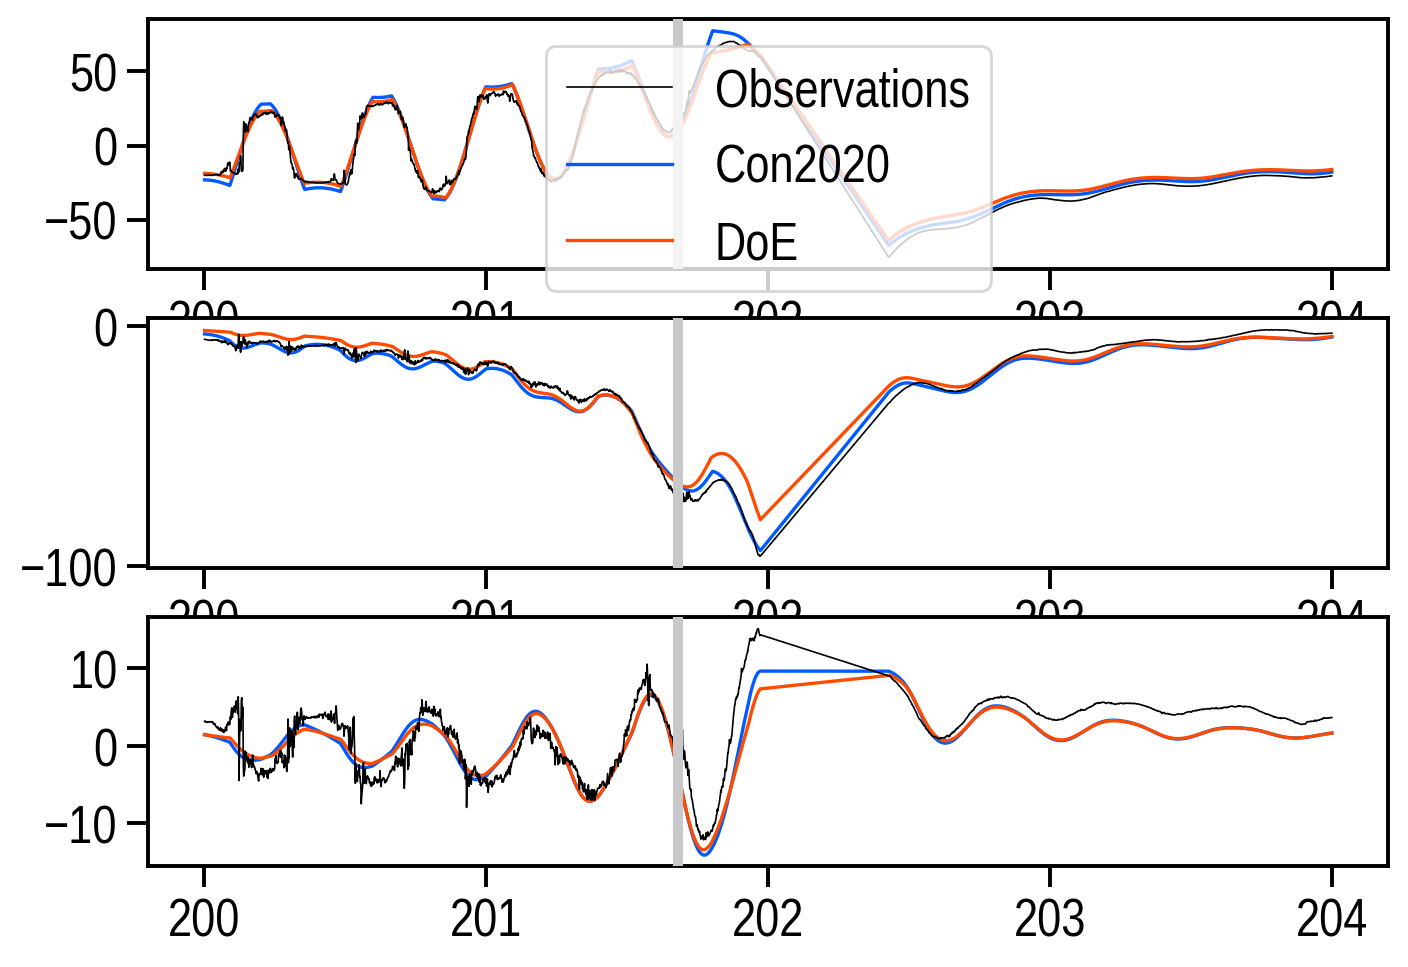

In [331]:
fig, ax = plt.subplots(3, 1, figsize=(8, 5.5), dpi=200)
ax[0].plot(time_arr, dBr, color='k',
           linewidth=0.6, label='Observations', zorder=2.0)
ax[0].plot(time_arr, dBr1_pc, color=UC.blue,
           linewidth=1.2, label='Con2020', zorder=1.0)
ax[0].plot(time_arr, dBr2_pc, color=UC.red,
           linewidth=1.2, label='DoE', zorder=1.0)
ax[1].plot(time_arr, dBtheta, color='k',
           linewidth=0.6, label='Obs', zorder=2.0)
ax[1].plot(time_arr, dBtheta1_pc, color=UC.blue,
           linewidth=1.2, label='Con2020', zorder=1.0)
ax[1].plot(time_arr, dBtheta2_pc, color=UC.red,
           linewidth=1.2, label='DoE', zorder=1.0)
ax[2].plot(time_arr, dBphi, color='k',
           linewidth=0.6, label='Obs', zorder=2.0)
ax[2].plot(time_arr, dBphi1_pc, color=UC.blue,
           linewidth=1.2, label='Con2020', zorder=1.0)
ax[2].plot(time_arr, dBphi2_pc, color=UC.red,
           linewidth=1.2, label='DoE', zorder=1.0)
ax[0].legend()
for i in range(3):
    ax[i].axvspan(xmin=time_arr[1195], xmax=time_arr[1220],
                  facecolor=UC.lightgray, zorder=3)

In [332]:
# RMSE（Root Mean Squared Error: 二乗平均平方根誤差）
print('Inbound')
print(
    math.sqrt(np.sum((dBr[:1374]-dBr1_pc[:1374])**2)/dBr[:1374].size))
print(
    math.sqrt(np.sum((dBr[:1374]-dBr2_pc[:1374])**2)/dBr[:1374].size))
print(
    math.sqrt(np.sum((dBtheta[:1374]-dBtheta1_pc[:1374])**2)/dBr[:1374].size))
print(
    math.sqrt(np.sum((dBtheta[:1374]-dBtheta2_pc[:1374])**2)/dBr[:1374].size))
print(
    math.sqrt(np.sum((dBphi[:1374]-dBphi1_pc[:1374])**2)/dBr[:1374].size))
print(
    math.sqrt(np.sum((dBphi[:1374]-dBphi2_pc[:1374])**2)/dBr[:1374].size))

print('Outbound')
print(math.sqrt(np.sum((dBr[1425:]-dBr1_pc[1425:])**2)/dBr[1425:].size))
print(math.sqrt(np.sum((dBr[1425:]-dBr2_pc[1425:])**2)/dBr[1425:].size))
print(
    math.sqrt(np.sum((dBtheta[1425:]-dBtheta1_pc[1425:])**2)/dBr[1425:].size))
print(
    math.sqrt(np.sum((dBtheta[1425:]-dBtheta2_pc[1425:])**2)/dBr[1425:].size))
print(math.sqrt(np.sum((dBphi[1425:]-dBphi1_pc[1425:])**2)/dBr[1425:].size))
print(math.sqrt(np.sum((dBphi[1425:]-dBphi2_pc[1425:])**2)/dBr[1425:].size))

Inbound
5.2942239411562655
4.499325394647394
2.8806221815802835
4.560168974658769
2.664459883695117
2.5767788495048505
Outbound
3.0764785674513777
5.7053410425746005
2.7459751778016885
2.496424149996711
2.2514470103089232
2.246754491481505


In [333]:
print(np.argsort(abs(r_pc-8.5)))

[1432 1360 1359 ...    2    1    0]


In [334]:
print(r_pc[1375])

8.023997939939905


In [335]:
r_ticks = np.array([[33, time_arr[90]],
                    [32, time_arr[159]],
                    [31, time_arr[227]],
                    [30, time_arr[293]],
                    [29, time_arr[358]],
                    [28, time_arr[421]],
                    [27, time_arr[483]],
                    [26, time_arr[544]],
                    [25, time_arr[603]],
                    [24, time_arr[660]],
                    [23, time_arr[716]],
                    [22, time_arr[770]],
                    [21, time_arr[823]],
                    [20, time_arr[875]],
                    [19, time_arr[925]],
                    [18, time_arr[974]],
                    [17, time_arr[1021]],
                    [16, time_arr[1067]],
                    [15, time_arr[1111]],
                    [14, time_arr[1154]],
                    [13, time_arr[1195]],
                    [12, time_arr[1235]],
                    [11, time_arr[1272]],
                    [10, time_arr[1309]],
                    [9, time_arr[1343]],
                    [8, time_arr[1375]],
                    [8, time_arr[1375]],
                    [9, time_arr[1449]],
                    [10, time_arr[1483]],
                    [11, time_arr[1519]],
                    [12, time_arr[1557]],
                    [13, time_arr[1597]],
                    [14, time_arr[1638]],
                    [15, time_arr[1680]],
                    [16, time_arr[1725]],
                    [17, time_arr[1770]],
                    [18, time_arr[1818]],
                    [19, time_arr[1865]],
                    [20, time_arr[1915]],
                    [21, time_arr[1967]],
                    [22, time_arr[2020]],
                    [23, time_arr[2075]],
                    [24, time_arr[2131]],
                    [25, time_arr[2189]],
                    [26, time_arr[2248]],
                    [27, time_arr[2308]],
                    [28, time_arr[2370]],
                    [29, time_arr[2433]],
                    [30, time_arr[2498]],])
print(r_ticks[1, :])

[ 32.         200.22256949]


In [336]:
print(time_arr)

[200.00173615 200.00312504 200.00451393 ... 203.99619206 203.99758095
 203.99896984]


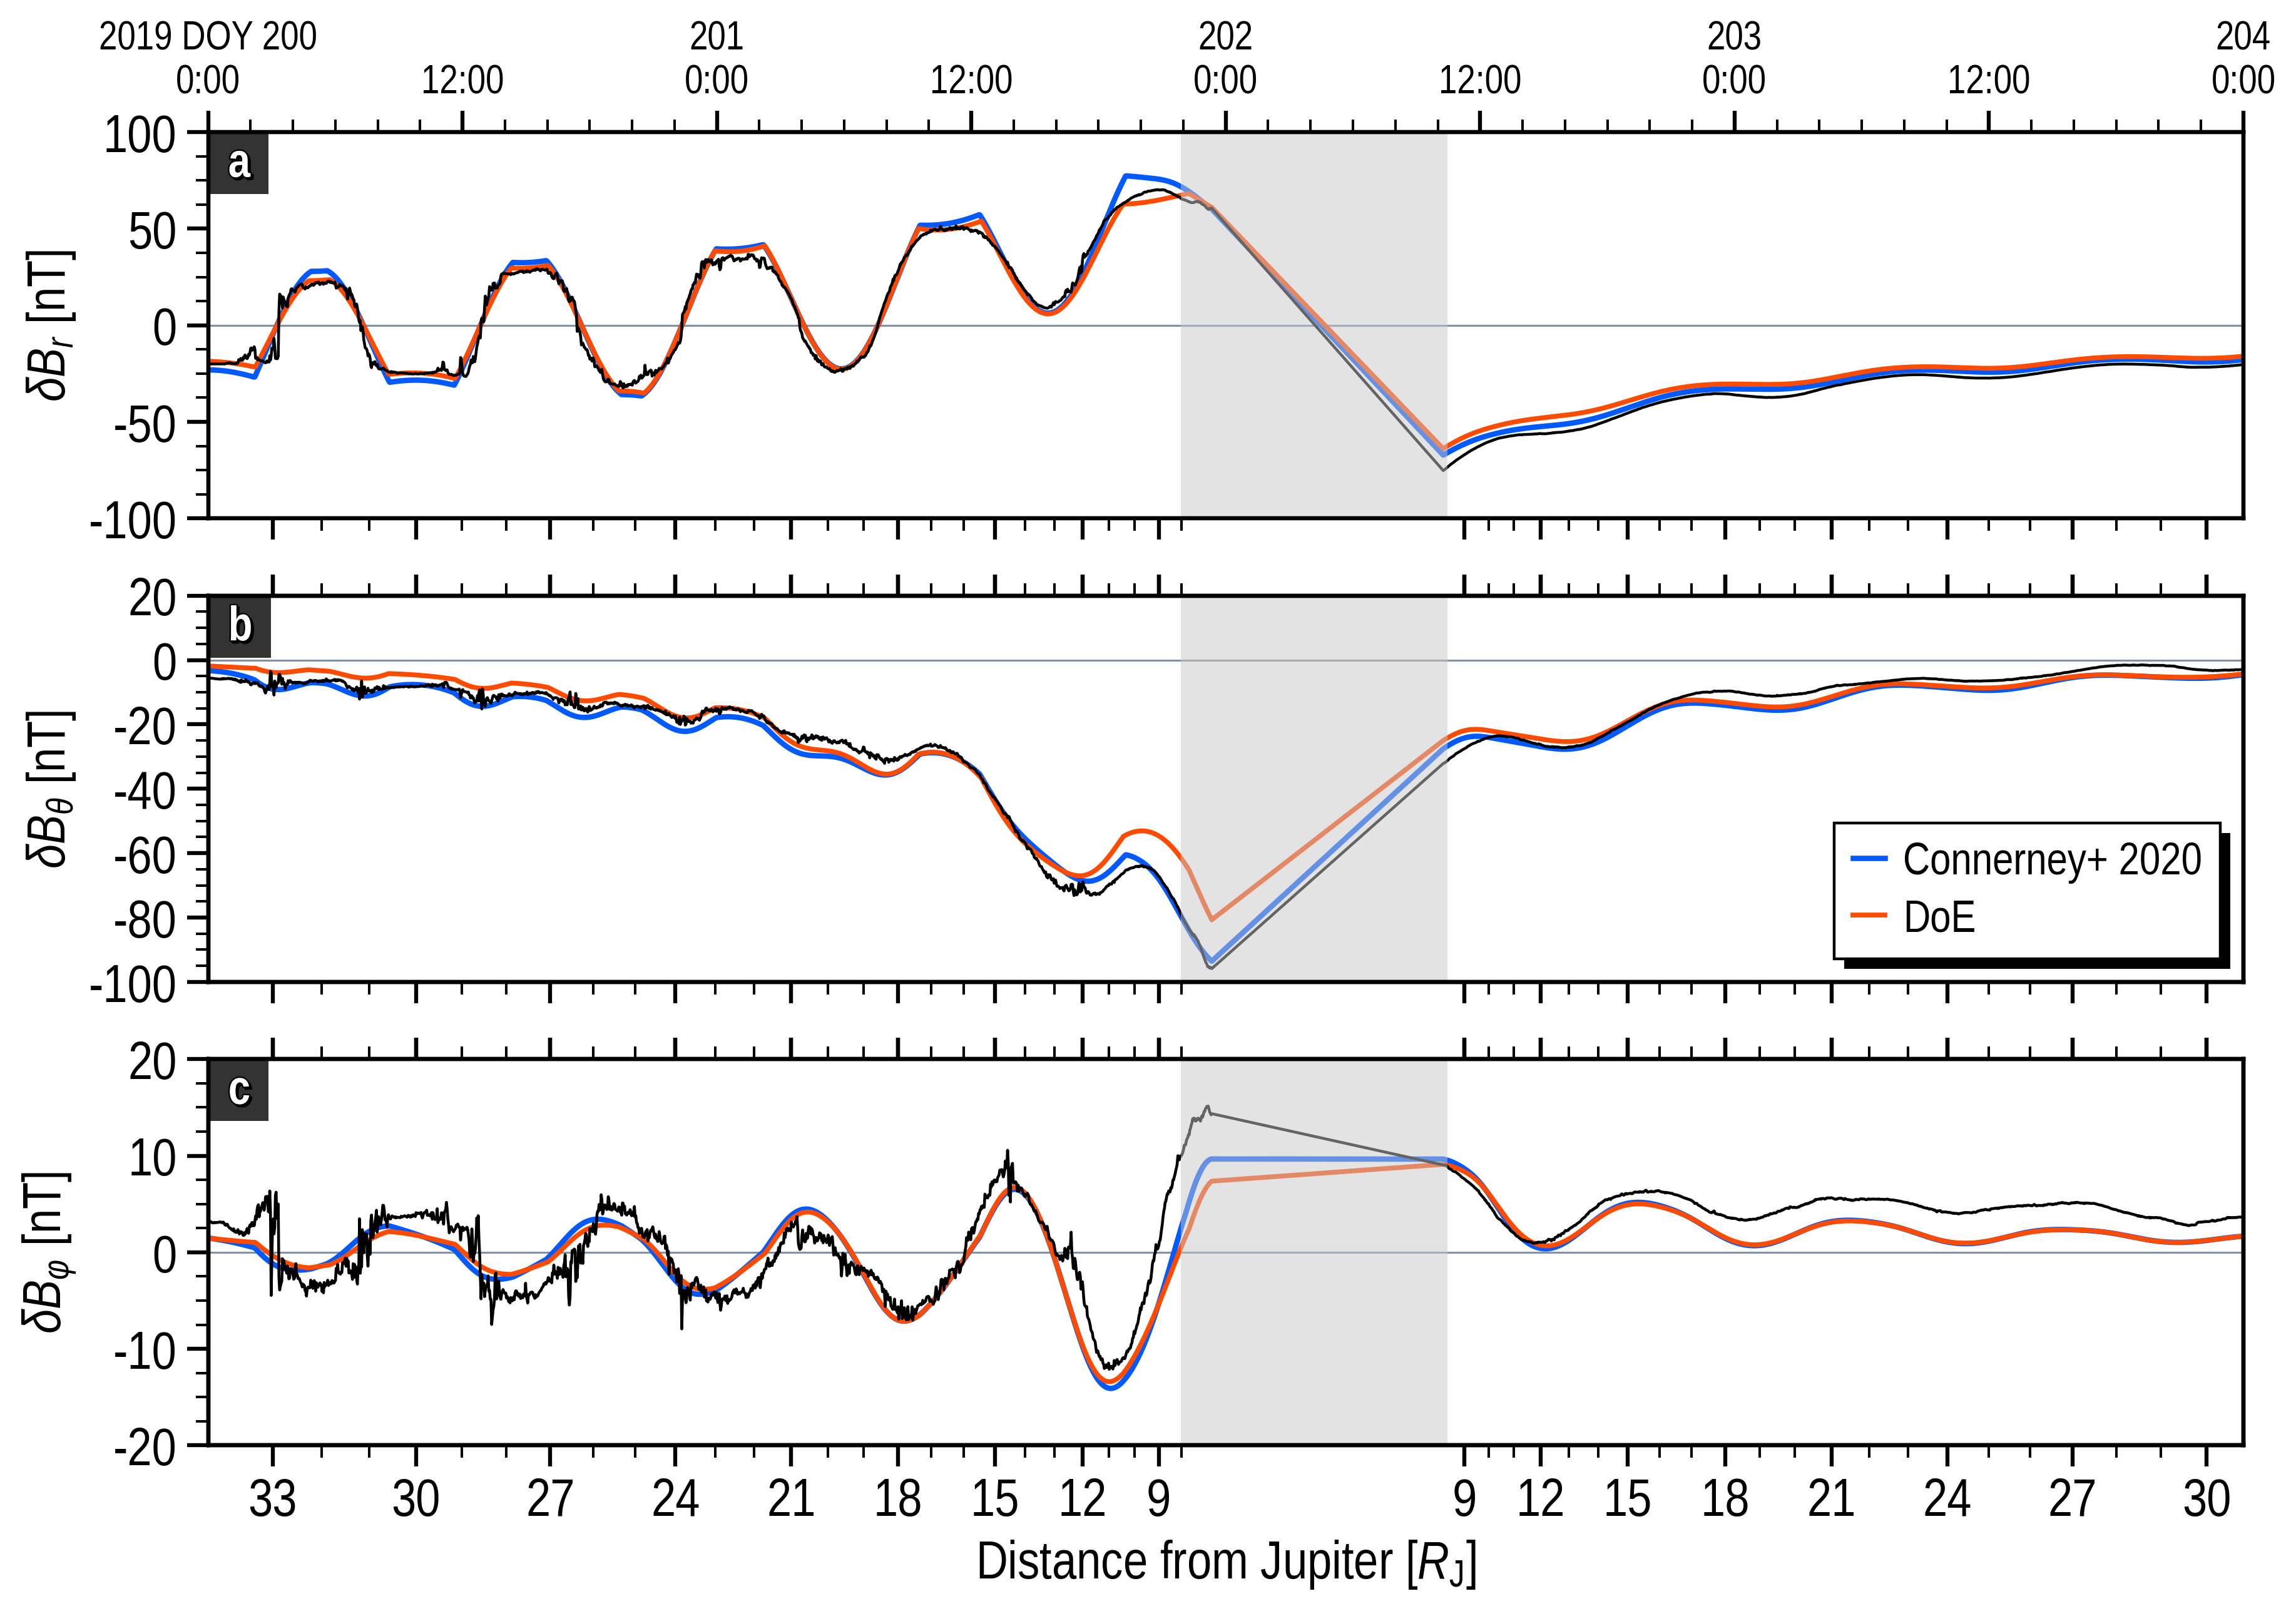

In [337]:
F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=3, figsize=(11.0, 7.5), dpi='XL')
F.hspace = 0.2
F.initialize()

xticks = r_ticks[::3, 1]
xticklabels = r_ticks[::3, 0].astype(int)

F.set_xaxis(label=r'Distance from Jupiter [$R_{\rm J}$]',
            min=200.0, max=204.0,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=None)
for i in range(3):
    F.ax[i].xaxis.set_minor_locator(FixedLocator(r_ticks[:, 1]))
for i in range(2):
    i += 1
    ax_upper = F.ax[i].twiny()
    ax_upper.set_xlim(200.0, 204.0)
    ax_upper.set_xticks(xticks)
    ax_upper.xaxis.set_minor_locator(FixedLocator(r_ticks[:, 1]))
    ax_upper.tick_params(labeltop=False)

F.set_yaxis(ax_idx=0,
            label=r'$\delta B_{r}$ [nT]',
            min=-100, max=100,
            ticks=np.linspace(-100, 100, 5),
            ticklabels=np.linspace(-100, 100, 5, dtype=int),
            minor_num=4)
F.set_yaxis(ax_idx=1,
            label=r'$\delta B_{\theta}$ [nT]',
            min=-100, max=20,
            ticks=np.linspace(-100, 20, 7),
            ticklabels=np.linspace(-100, 20, 7, dtype=int),
            minor_num=4)
F.set_yaxis(ax_idx=2,
            label=r'$\delta B_{\varphi}$ [nT]',
            min=-20, max=20,
            ticks=np.linspace(-20, 20, 5),
            ticklabels=np.linspace(-20, 20, 5, dtype=int),
            minor_num=4)
F.ax[0].plot(time_arr, dBr, color='k',
             linewidth=1.0, label='Observations', zorder=2.0)
F.ax[0].plot(time_arr, dBr1_pc, color=UC.blue,
             linewidth=1.9, label='Connerney+ 2020', zorder=1.0)
F.ax[0].plot(time_arr, dBr2_pc, color=UC.red,
             linewidth=1.7, label='DoE', zorder=1.0)
F.ax[1].plot(time_arr, dBtheta, color='k',
             linewidth=1.0, zorder=2.0)
F.ax[1].plot(time_arr, dBtheta1_pc, color=UC.blue,
             linewidth=1.9, label='Connerney+ 2020', zorder=1.0)
F.ax[1].plot(time_arr, dBtheta2_pc, color=UC.red,
             linewidth=1.7, label='DoE', zorder=1.0)
F.ax[2].plot(time_arr, dBphi, color='k',
             linewidth=1.0, label='Observations', zorder=2.0)
F.ax[2].plot(time_arr, dBphi1_pc, color=UC.blue,
             linewidth=1.9, label='Connerney+ 2020', zorder=1.0)
F.ax[2].plot(time_arr, dBphi2_pc, color=UC.red,
             linewidth=1.7, label='DoE', zorder=1.0)

# Shades near Jupiter
for i in range(F.nrows):
    F.ax[i].axvspan(time_arr[1374], time_arr[1425],
                    fc=UC.lightgray, ec=None,
                    alpha=0.5, zorder=2.5)

# y = 0 line
for i in range(F.nrows):
    F.ax[i].axhline(y=0.0, color=UC.gray, linewidth=0.7, zorder=0.9)

# Time axis
timeax = F.ax[0].twiny()
timeax.set_xlim(200.0, 204.0)
timeax.set_xticks([200.0, 200.5,
                   201.0, 201.5, 202.0, 202.5,
                   203.0, 203.5, 204.0])
timeax.set_xticklabels(['2019 DOY 200\n0:00', '12:00',
                        '201\n0:00', '12:00', '202\n0:00', '12:00',
                        '203\n0:00', '12:00', '204\n0:00'], fontsize=F.fontsize*0.75)
timeax.xaxis.set_minor_locator(ptick.AutoMinorLocator(6))

legend = F.legend(ax_idx=1,
                  ncol=1, markerscale=1.0,
                  loc='lower right',
                  handlelength=0.7,
                  textcolor=False,
                  fontsize_scale=0.85,
                  handletextpad=0.4)
legend_shadow(legend=legend, fig=F.fig, ax=F.ax[0], d=0.7)